## import packages

In [1]:
import numpy as np
import pandas as pd
from typing import Optional, Tuple
import sys

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

from pickle import dump
from sklearn.preprocessing import MinMaxScaler
import time
from tqdm import tqdm

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import os

#device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("cuda is available")
else:
    print("cuda is NOT available")

#device = torch.device("cuda:0")


import shutil
import warnings
import pickle

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)

from nn_functions import surrogate
from moving_average import moving_average_1d
import copy
from GAMMA_obj_temp_depth import GAMMA_obj

import sys
sys.path.append('../1_model')
from TiDE import TideModule, quantile_loss, TiDE_forward

import importlib
import policy
importlib.reload(policy)
from policy import PolicyNN


cuda is available


In [2]:
device = torch.device("cpu") 
print("torch current:", torch.cuda.current_device())
import os, torch
print(os.environ.get("CUDA_VISIBLE_DEVICES"), torch.cuda.device_count(), torch.cuda.get_device_name(0))


torch current: 0
None 8 NVIDIA RTX A6000


In [3]:
import os, torch
print("CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("device_count =", torch.cuda.device_count())
print("current_device =", torch.cuda.current_device() if torch.cuda.is_available() else None)
if torch.cuda.is_available():
    print("name(0) =", torch.cuda.get_device_name(0))


CUDA_VISIBLE_DEVICES = None
device_count = 8
current_device = 0
name(0) = NVIDIA RTX A6000


## define funcitons

In [4]:
# values from user
x_min = torch.tensor([[0.0, 0.75, 0.75, 504.26]], dtype=torch.float32).to(device)
x_max = torch.tensor([[7.5, 20.0, 20.0, 732.298]], dtype=torch.float32).to(device)

y_min = torch.tensor([[436.608, -0.559]], dtype=torch.float32).to(device)
y_max = torch.tensor([[4509.855, 0.551]], dtype=torch.float32).to(device)


In [5]:
import os, torch
print("CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("device_count =", torch.cuda.device_count())
print("current_device =", torch.cuda.current_device() if torch.cuda.is_available() else None)
if torch.cuda.is_available():
    print("name(0) =", torch.cuda.get_device_name(0))


CUDA_VISIBLE_DEVICES = None
device_count = 8
current_device = 0
name(0) = NVIDIA RTX A6000


In [6]:
def normalize_x(x, dim_id):
    x_min_selected = x_min[0, dim_id]
    x_max_selected = x_max[0, dim_id]
    return 2 * (x - x_min_selected) / (x_max_selected - x_min_selected) - 1

def inverse_normalize_x(x_norm, dim_id):
    x_min_selected = x_min[0, dim_id]
    x_max_selected = x_max[0, dim_id]
    return 0.5 * (x_norm + 1) * (x_max_selected - x_min_selected) + x_min_selected

def normalize_y(y, dim_id):
    y_min_selected = y_min[0, dim_id]
    y_max_selected = y_max[0, dim_id]
    return 2 * (y - y_min_selected) / (y_max_selected - y_min_selected) - 1

def inverse_normalize_y(y_norm, dim_id):
    y_min_selected = y_min[0, dim_id]
    y_max_selected = y_max[0, dim_id]
    return 0.5 * (y_norm + 1) * (y_max_selected - y_min_selected) + y_min_selected


In [7]:
import numpy as np

# ───────── 측정 노이즈 설정 (state 변수별, 물리 스케일 기준) ─────────
# temperature 범위 ≈ [437, 4510] K,  depth 범위 ≈ [-0.559, 0.551] mm  → 스케일이 매우 다름
ADD_MEAS_NOISE  = True
MEAS_NOISE_MODE = "absolute"                      # "absolute" 또는 "relative"
MEAS_NOISE_STD  = {"temp": 20.0,  "depth": 0.005} # 절대 std (K, mm). ★실측 센서 노이즈에 맞게 튜닝
MEAS_NOISE_REL  = {"temp": 0.01,  "depth": 0.02}  # 상대 std(값의 비율). mode="relative"일 때 사용
NOISE_SEED_BASE = 1000                            # 재현성용 (laser별로 seed 분리)

def add_meas_noise(temp, depth, rng=None):
    """GAMMA 참값(temp, depth)에 측정 노이즈를 더해 (noisy_temp, noisy_depth) 반환."""
    t, d = float(temp), float(depth)
    if not ADD_MEAS_NOISE:
        return t, d
    g = rng if rng is not None else np.random
    if MEAS_NOISE_MODE == "relative":
        t_std, d_std = abs(t) * MEAS_NOISE_REL["temp"], abs(d) * MEAS_NOISE_REL["depth"]
    else:
        t_std, d_std = MEAS_NOISE_STD["temp"], MEAS_NOISE_STD["depth"]
    return t + g.normal(0.0, t_std), d + g.normal(0.0, d_std)

In [8]:
def run_one_step_policy(GAMMA_obj, policy_model, P, window):
    # Reference trajectory for temperature (original scale)
    mp_temp_ref = GAMMA_obj.ref[GAMMA_obj.MPC_counter:GAMMA_obj.MPC_counter + P]
    mp_temp_ref_t = torch.as_tensor(mp_temp_ref, dtype=torch.float32, device=device).reshape(1, P, 1)

    # Past input (original scale)
    mp_temp_past_t = GAMMA_obj.x_past.T.unsqueeze(0).to(device)
    laser_past_t = GAMMA_obj.u_past.view(1, -1, 1).to(device)
    fix_cov_past = GAMMA_obj.fix_cov_all[GAMMA_obj.MPC_counter - window:GAMMA_obj.MPC_counter, :]
    fix_cov_past_t = torch.as_tensor(fix_cov_past, dtype=torch.float32, device=device).unsqueeze(0)

    # Normalize
    fix_cov_past_s = normalize_x(fix_cov_past_t, dim_id=[0, 1, 2])
    laser_past_s = normalize_x(laser_past_t, dim_id=[3])
    mp_temp_past_s = normalize_y(mp_temp_past_t, dim_id=[0, 1])

    policy_in_past = torch.cat((fix_cov_past_s, laser_past_s, mp_temp_past_s), dim=2)

    # Future covariates
    fix_cov_future = GAMMA_obj.fix_cov_all[GAMMA_obj.MPC_counter:GAMMA_obj.MPC_counter + P, :]
    fix_cov_future_t = torch.as_tensor(fix_cov_future, dtype=torch.float32, device=device).unsqueeze(0)
    fix_cov_future_s = normalize_x(fix_cov_future_t, dim_id=[0, 1, 2])
    mp_temp_ref_s = normalize_y(mp_temp_ref_t, dim_id=[0])[:, :, 0].unsqueeze(-1)

    depth_lower_const = 0.1423
    depth_upper_const = 0.4126
    y_const_s = torch.tensor([[depth_lower_const, depth_upper_const]] * P, dtype=torch.float32, device=device).reshape(1, P, 2)

    policy_in_future = torch.cat((fix_cov_future_s, mp_temp_ref_s, y_const_s), dim=2)

    # ✅ Policy inference 시간 측정 (순수 forward만)
    t1 = time.time()
    u_pred = policy_model((policy_in_past, policy_in_future))
    t2 = time.time()
    GAMMA_obj.save_time.append(t2 - t1)


    # 현재 예측된 첫 control (normalized 상태)
    u_first = u_pred[0, 0]

    # 이전 control
    u_prev = normalize_x(GAMMA_obj.u_past[-1].view(1,1,1).to(device), dim_id=[3])[0,0,0]

    # delta clamp
    delta_max = 0.05
    delta = u_first - u_prev
    delta_clamped = torch.clamp(delta, -delta_max, delta_max)
    u_first_limited = u_prev + delta_clamped

    u_applied = float(inverse_normalize_x(u_first_limited, dim_id=[3]))
    
    #############################
    # # Simulate one step
    # x_current, depth_current = GAMMA_obj.run_sim_interval(u_applied)

    # # Update past sequence
    # GAMMA_obj.x_past[:, :-1] = GAMMA_obj.x_past[:, 1:]
    # GAMMA_obj.x_past[0, -1] = x_current
    # GAMMA_obj.x_past[1, -1] = depth_current

    #############################
    # Simulate one step (GAMMA = ground truth)
    x_true, depth_true = GAMMA_obj.run_sim_interval(u_applied)

    # ── 측정 노이즈 추가 (closed-loop): 노이즈 낀 값을 '센서 측정값'으로 사용 ──
    rng = getattr(GAMMA_obj, "meas_rng", None)
    x_current, depth_current = add_meas_noise(x_true, depth_true, rng=rng)

    # Update past sequence (정책은 노이즈 낀 측정값을 본다)
    GAMMA_obj.x_past[:, :-1] = GAMMA_obj.x_past[:, 1:]
    GAMMA_obj.x_past[0, -1] = x_current
    GAMMA_obj.x_past[1, -1] = depth_current
    #############################

    GAMMA_obj.u_past[:-1] = GAMMA_obj.u_past[1:].clone()
    GAMMA_obj.u_past[-1] = u_applied

    # Save state
    GAMMA_obj.x_hat_current = torch.tensor([x_current, depth_current], device=device)
    GAMMA_obj.x_sys_current = torch.tensor([[x_current], [depth_current]], device=device)
    GAMMA_obj.MPC_counter += 1

    new_state = torch.tensor([[x_current, depth_current]], device=GAMMA_obj.x_past_save.device)
    GAMMA_obj.x_past_save = torch.cat((GAMMA_obj.x_past_save, new_state), dim=0)

    new_u = torch.tensor([[u_applied]], device=GAMMA_obj.u_past_save.device)
    GAMMA_obj.u_past_save = torch.cat((GAMMA_obj.u_past_save, new_u), dim=0)
    

In [9]:
import os
import matplotlib.pyplot as plt
import numpy as np

def plot_fig(MPC_GAMMA, N_step, save_path=None):
    plt.figure(figsize=[8, 6])

    plt.subplot(3, 1, 1)
    plt.plot(MPC_GAMMA.x_past_save[:N_step, 0].detach().cpu().numpy(), label="GAMMA simulation")
    plt.plot(MPC_GAMMA.ref[:N_step].detach().cpu().numpy(), label="Reference")
    plt.legend()
    plt.xlabel("MPC time step")
    plt.ylabel("Melt Pool Temperature (K)")

    plt.subplot(3, 1, 2)
    plt.plot(MPC_GAMMA.x_past_save[:N_step, 1].detach().cpu().numpy(), label="GAMMA simulation")
    plt.plot(np.arange(N_step), 0.225 * np.ones(N_step), linestyle='--', label="Upper Bound")
    plt.plot(np.arange(N_step), 0.075 * np.ones(N_step), linestyle='--', label="Lower Bound")
    plt.xlabel("MPC time step")
    plt.ylabel("Melt Pool Depth (mm)")
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.plot(MPC_GAMMA.u_past_save[:N_step].detach().cpu().numpy())
    plt.ylabel("Laser Power (W)")
    plt.xlabel("MPC time step")

    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        plt.close()
        print(f"Saved plot to {save_path}")
    else:
        plt.show()


In [10]:
import os, torch
print("CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("device_count =", torch.cuda.device_count())
print("current_device =", torch.cuda.current_device() if torch.cuda.is_available() else None)
if torch.cuda.is_available():
    print("name(0) =", torch.cuda.get_device_name(0))


CUDA_VISIBLE_DEVICES = None
device_count = 8
current_device = 0
name(0) = NVIDIA RTX A6000


## run loop

In [11]:
import os, torch
print("CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("device_count =", torch.cuda.device_count())
print("current_device =", torch.cuda.current_device() if torch.cuda.is_available() else None)
if torch.cuda.is_available():
    print("name(0) =", torch.cuda.get_device_name(0))


CUDA_VISIBLE_DEVICES = None
device_count = 8
current_device = 0
name(0) = NVIDIA RTX A6000


In [12]:
# print(f"device: {device}")
# print(f"model device: {next(model.parameters()).device}")
# print(f"x_min device: {x_min.device}")
# print(f"y_min device: {y_min.device}")
# print(f"init_avg device: {init_avg.device}")
# print(f"fix_covariates device: {fix_covariates.device}")
# print(f"mp_temp_ref device: {mp_temp_ref.device}")

100%|██████████| 250/250 [00:05<00:00, 45.83it/s]


[WARN] laser 1: 'melt_pool_depth' column not found -> skip depth.
[DEBUG] laser 1 save types:
  x_past_save: <class 'torch.Tensor'>
  u_past_save: <class 'torch.Tensor'>
  ref: <class 'torch.Tensor'>


Laser 1:   0%|          | 0/6195 [00:00<?, ?it/s]

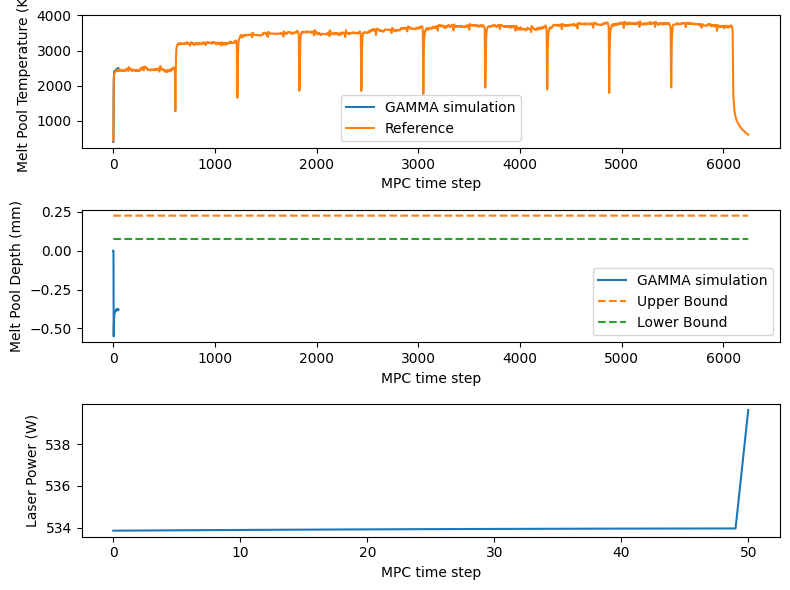

Laser 1:   8%|▊         | 500/6195 [00:56<10:44,  8.84it/s]

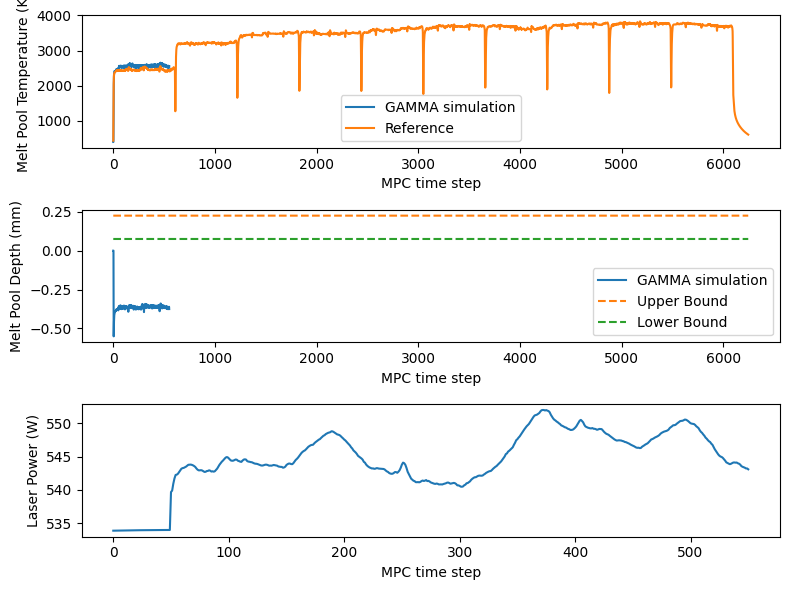

Laser 1:  16%|█▌        | 1000/6195 [01:54<10:05,  8.58it/s]

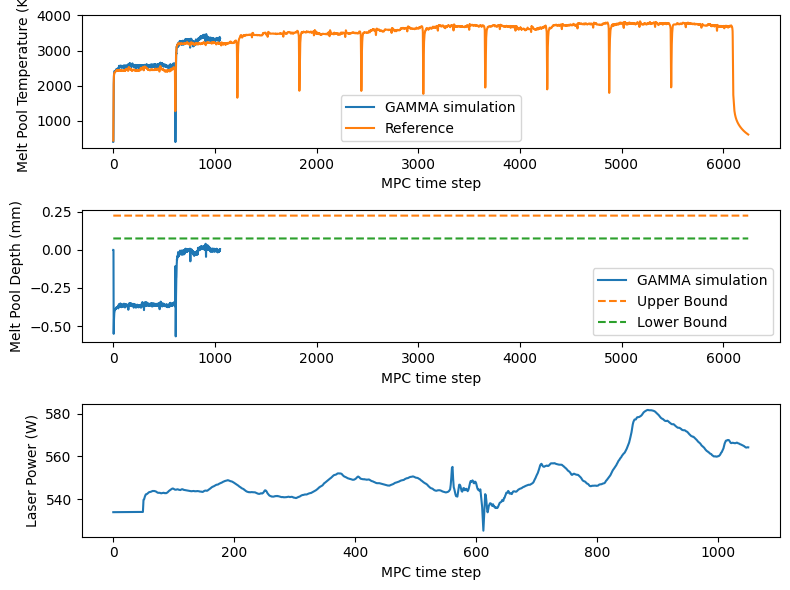

Laser 1:  24%|██▍       | 1500/6195 [02:55<09:34,  8.17it/s]

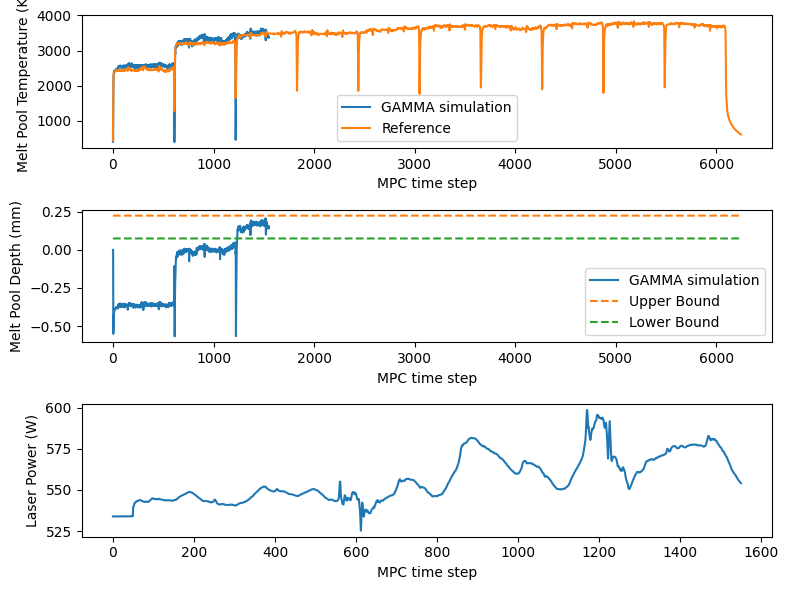

Laser 1:  32%|███▏      | 2000/6195 [03:57<08:44,  8.00it/s]

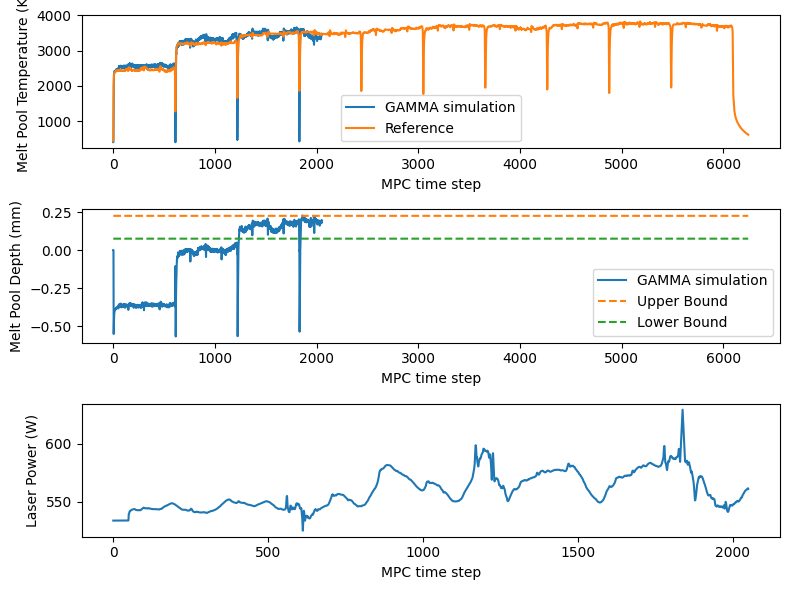

Laser 1:  40%|████      | 2500/6195 [05:01<07:58,  7.72it/s]

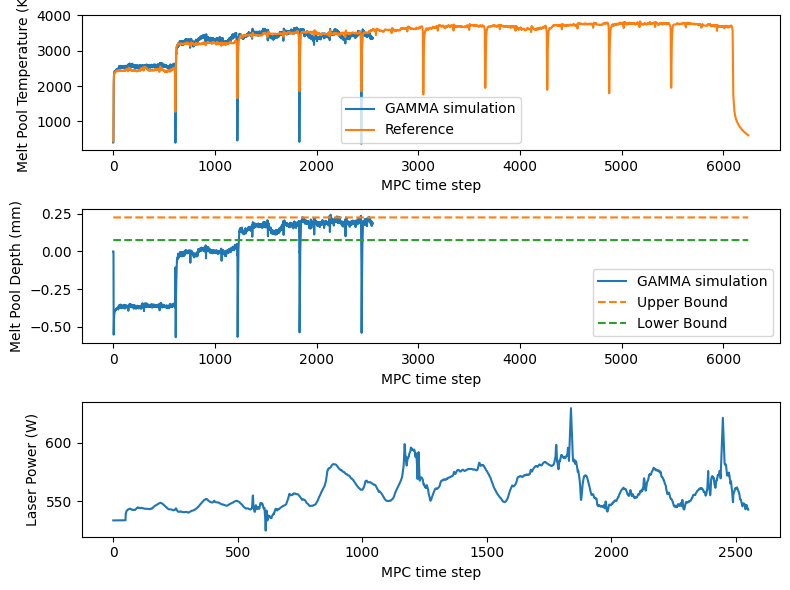

Laser 1:  48%|████▊     | 3000/6195 [06:07<06:20,  8.40it/s]

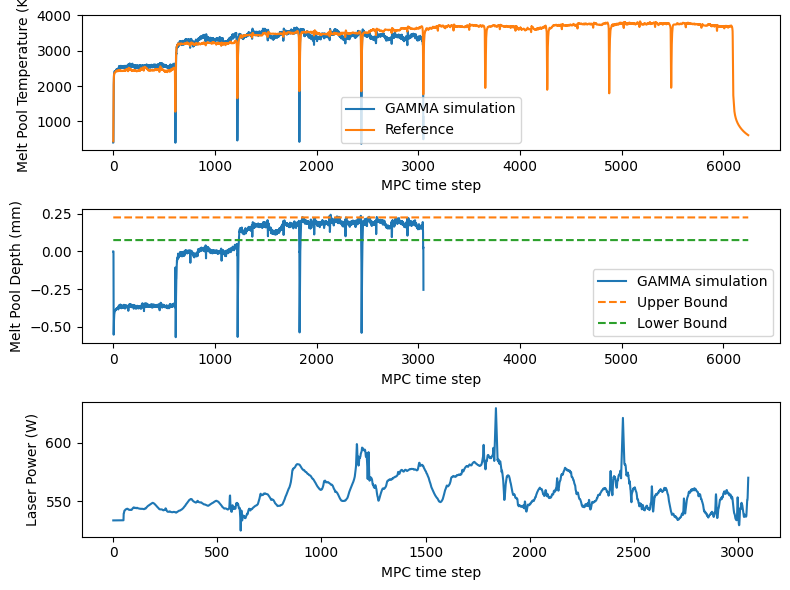

Laser 1:  56%|█████▋    | 3500/6195 [07:13<06:00,  7.48it/s]

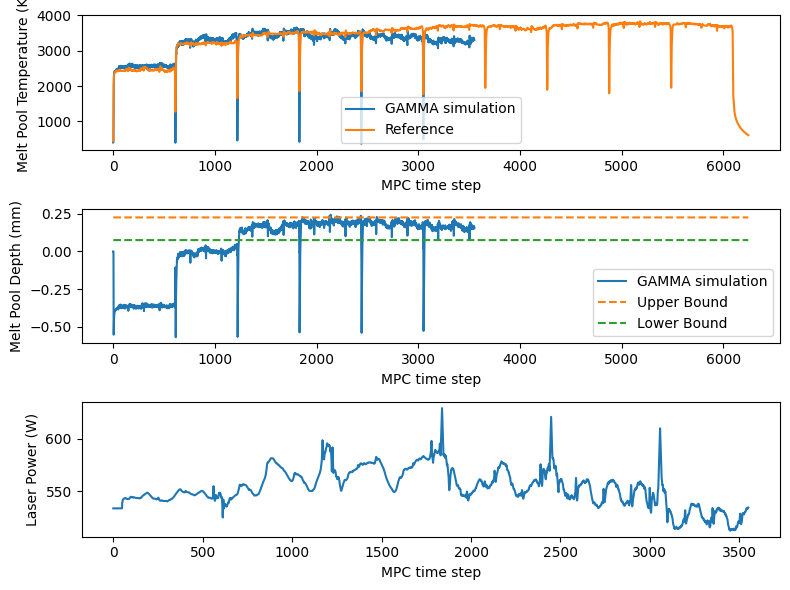

Laser 1:  65%|██████▍   | 4000/6195 [08:20<04:56,  7.39it/s]

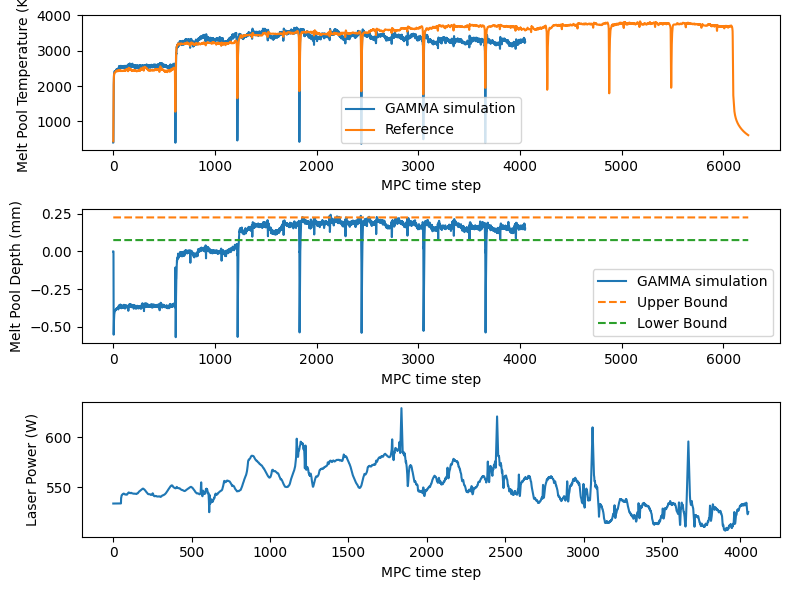

Laser 1:  73%|███████▎  | 4500/6195 [09:29<03:53,  7.26it/s]

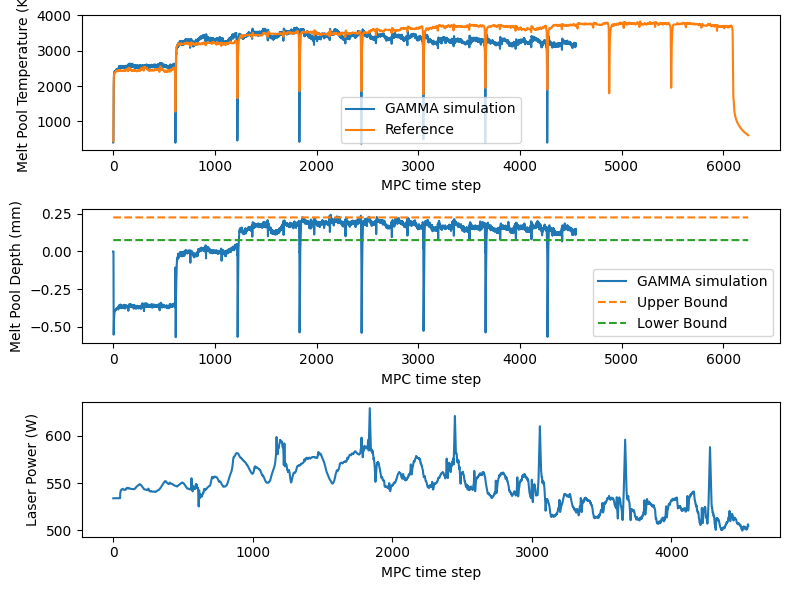

Laser 1:  81%|████████  | 5000/6195 [10:39<02:48,  7.10it/s]

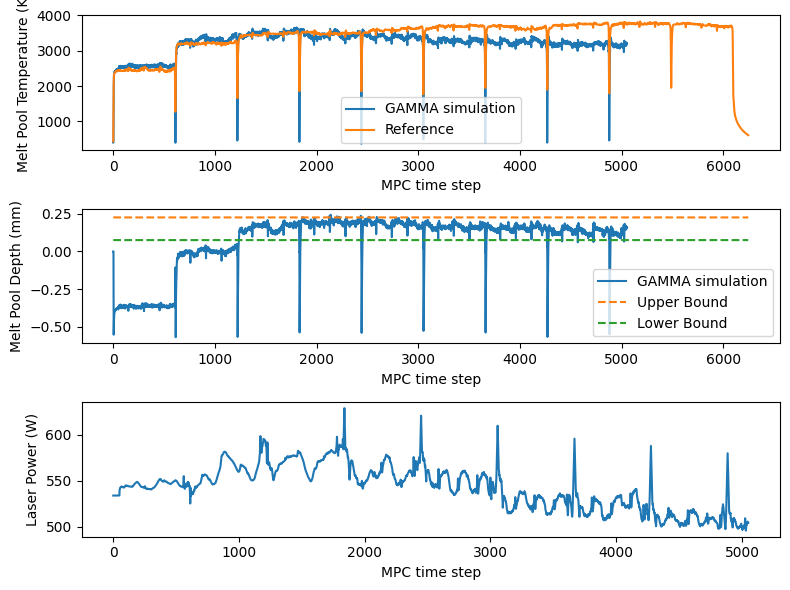

Laser 1:  89%|████████▉ | 5500/6195 [11:50<01:38,  7.07it/s]

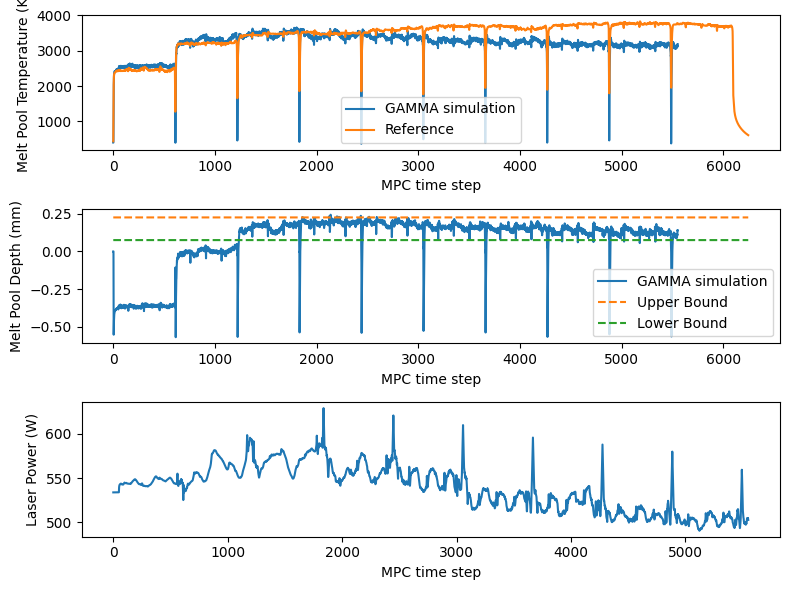

Laser 1:  97%|█████████▋| 6000/6195 [13:02<00:28,  6.91it/s]

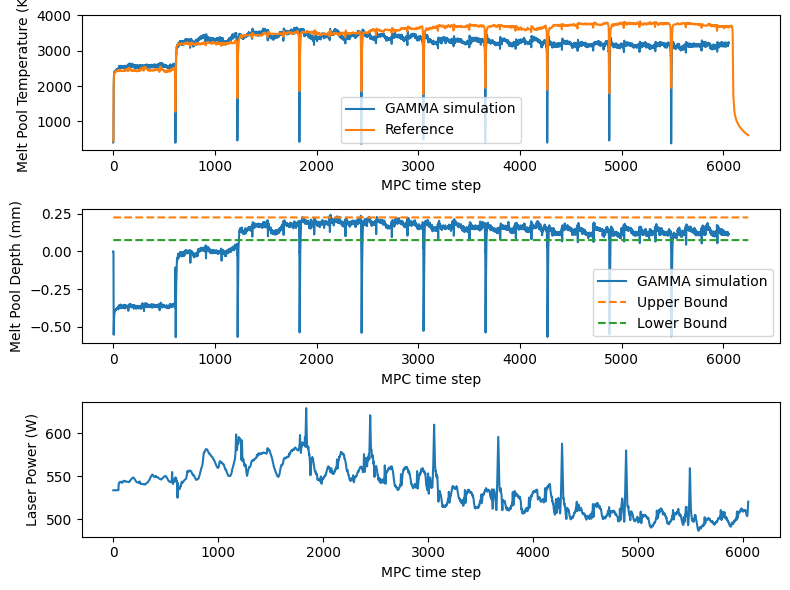

Laser 1: 100%|██████████| 6195/6195 [13:28<00:00,  7.66it/s]


Saved plot to /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/time/addnoise/policy_roll_epoch0049.pth_clamped(1)/final_plot_laser_1.png
              Time
count  6195.000000
mean      0.000541
std       0.000095
min       0.000458
25%       0.000504
50%       0.000528
75%       0.000544
max       0.002683
✅ Completed and saved for laser_power_number 1


In [13]:


# ── Constants ─────────────────────────────────────
INPUT_DATA_DIR = "data"
SIM_DIR_NAME = "single_track_square"
BASE_LASER_FILE_DIR = "laser_power_profiles/csv"
CLOUD_TARGET_BASE_PATH = "result"
solidus_temp = 1600
window = 50
sim_interval = 5
init_runs = 50
P = 50

model_path = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/policy_roll_epoch0049.pth"

# ── Load model ─────────────────────────────────────
ckpt = torch.load(model_path, map_location=device)
model = PolicyNN(
    past_input_dim=6,
    future_input_dim=6,
    output_dim=1,
    p=P,
    window=window,
    hidden_dim=1024,
    n_layers=3,
    dropout_p=0.0
).to(device)

state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)

#ckpt = torch.load(model_path)
#model.load_state_dict(ckpt["model_state_dict"])


model.eval()

# ── Output directory ───────────────────────────────
save_dir = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/time/addnoise/policy_roll_epoch0049.pth_clamped(1)"
os.makedirs(save_dir, exist_ok=True)

# ── Loop over laser_power_number 2 to 30 ───────────
for laser_num in range(1,2):
    try:
        # Step 1: Load input CSV
        csv_path = f"/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/split_by_laser_power_number/laser_power_number_{laser_num}.csv"
        df = pd.read_csv(csv_path)

        # Step 2: Instantiate GAMMA class
        GAMMA_class = GAMMA_obj(INPUT_DATA_DIR, SIM_DIR_NAME, BASE_LASER_FILE_DIR,
                                CLOUD_TARGET_BASE_PATH, solidus_temp, window,
                                init_runs, sim_interval, laser_power_number=laser_num)

        # Step 3: Run initial steps
        init_avg = GAMMA_class.run_initial_steps()
        init_avg = torch.tensor(init_avg, dtype=torch.float32).to(device)[:, -window:]

        # Step 4: Prepare inputs
        loc_Z = df["Z"].to_numpy().reshape(-1, 1)
        dist_X = df["Dist_to_nearest_X"].to_numpy().reshape(-1, 1)
        dist_Y = df["Dist_to_nearest_Y"].to_numpy().reshape(-1, 1)
        fix_covariates = torch.tensor(np.concatenate((loc_Z, dist_X, dist_Y), axis=1), dtype=torch.float32).to(device)

        laser_power_ref = torch.tensor(df["Laser_power"].to_numpy().reshape(-1, 1), dtype=torch.float32).to(device)
        laser_power_past = laser_power_ref[:window]

        mp_temp_raw = df["melt_pool_temperature"].to_numpy()
        mp_temp = copy.deepcopy(mp_temp_raw)
        mp_temp[1:-2] = moving_average_1d(mp_temp_raw, 4)
        mp_temp_ref = torch.tensor(mp_temp, dtype=torch.float32).to(device)

        # ---- depth는 있으면 만들고, 없으면 스킵 ----
        if "melt_pool_depth" in df.columns:
            mp_depth_raw = df["melt_pool_depth"].to_numpy()
            mp_depth = copy.deepcopy(mp_depth_raw)
            mp_depth[1:-2] = moving_average_1d(mp_depth_raw, 4)
            mp_depth_ref = torch.tensor(mp_depth, dtype=torch.float32).to(device)
        else:
            mp_depth_ref = None
            print(f"[WARN] laser {laser_num}: 'melt_pool_depth' column not found -> skip depth.")


        # Step 5: Initialize GAMMA_class variables
        GAMMA_class.ref = mp_temp_ref.clone().to(device)
        GAMMA_class.fix_cov_all = fix_covariates.clone().to(device)
        GAMMA_class.x_past = init_avg.clone().to(device)
        GAMMA_class.u_past = laser_power_past.clone().to(device)
        GAMMA_class.x_past_save = GAMMA_class.x_past.T.clone().to(device)
        GAMMA_class.u_past_save = GAMMA_class.u_past.clone().to(device)
        GAMMA_class.MPC_counter = window
        GAMMA_class.x_hat_current = GAMMA_class.x_past[:, -1].to(device)
        GAMMA_class.x_sys_current = GAMMA_class.x_past[:, -1].reshape(2, 1).to(device)
        GAMMA_class.save_time = []

        # 측정 노이즈용 RNG (laser별 seed 분리 → 재현 가능)
        GAMMA_class.meas_rng = np.random.default_rng(NOISE_SEED_BASE + laser_num)
        # (선택) ground truth 저장 버퍼 — x_past_save와 동일하게 시작
        GAMMA_class.x_true_save = GAMMA_class.x_past_save.clone()

        print(f"[DEBUG] laser {laser_num} save types:")
        print("  x_past_save:", type(GAMMA_class.x_past_save))
        print("  u_past_save:", type(GAMMA_class.u_past_save))
        print("  ref:", type(GAMMA_class.ref))


        # Step 6: Run simulation loop
        N_step = len(mp_temp_ref) - P
        for i in tqdm(range(N_step - P), desc=f"Laser {laser_num}"):
            run_one_step_policy(GAMMA_class, model, P=P, window=window)
            if i % 500 == 0:
                plot_fig(GAMMA_class, N_step)   # ✅ 중간 출력(화면) 그대로

        # ✅ 최종 플롯만 save_dir에 저장
        final_plot_path = os.path.join(save_dir, f"final_plot_laser_{laser_num}.png")
        plot_fig(GAMMA_class, N_step, save_path=final_plot_path)

        # Step 7: Save outputs
        x_save = GAMMA_class.x_past_save.detach().cpu().numpy()
        u_save = GAMMA_class.u_past_save.detach().cpu().numpy()
        ref_save = GAMMA_class.ref.detach().cpu().numpy()

        # ✅ 시간 저장
        df_time = pd.DataFrame({'Time': GAMMA_class.save_time})
        print(df_time.describe())  # 평균/min/max 바로 확인
        df_time.to_csv(
            os.path.join(save_dir, f"policy_time_laser_{laser_num}.csv"), index=False)

        pd.DataFrame(x_save).to_csv(
            os.path.join(save_dir, f"x_outputs_laser_{laser_num}.csv"), index=False)
        pd.DataFrame(u_save).to_csv(
            os.path.join(save_dir, f"u_outputs_laser_{laser_num}.csv"), index=False)
        pd.DataFrame(ref_save).to_csv(
            os.path.join(save_dir, f"ref_laser_{laser_num}.csv"), index=False)
        # (선택) ground truth 저장
        if hasattr(GAMMA_class, "x_true_save"):
            xtrue_save = GAMMA_class.x_true_save.detach().cpu().numpy()
            pd.DataFrame(xtrue_save).to_csv(
                os.path.join(save_dir, f"x_true_outputs_laser_{laser_num}.csv"), index=False)


        print(f"✅ Completed and saved for laser_power_number {laser_num}")

    except Exception as e:
        print(f"❌ Error in laser_power_number {laser_num}: {e}")


100%|██████████| 250/250 [00:05<00:00, 45.89it/s]


[WARN] laser 1: 'melt_pool_depth' column not found -> skip depth.
[DEBUG] laser 1 save types:
  x_past_save: <class 'torch.Tensor'>
  u_past_save: <class 'torch.Tensor'>
  ref: <class 'torch.Tensor'>


Laser 1:   0%|          | 0/6195 [00:00<?, ?it/s]

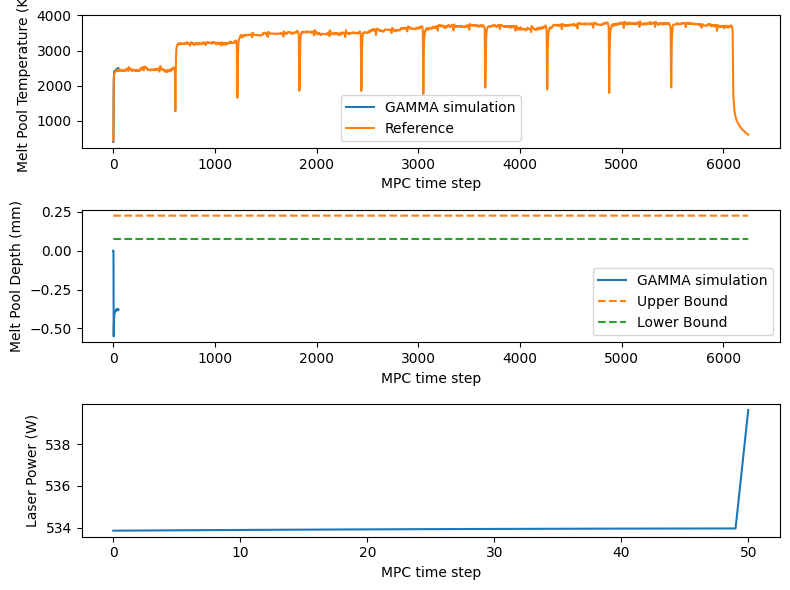

Laser 1:   8%|▊         | 500/6195 [00:57<10:55,  8.69it/s]

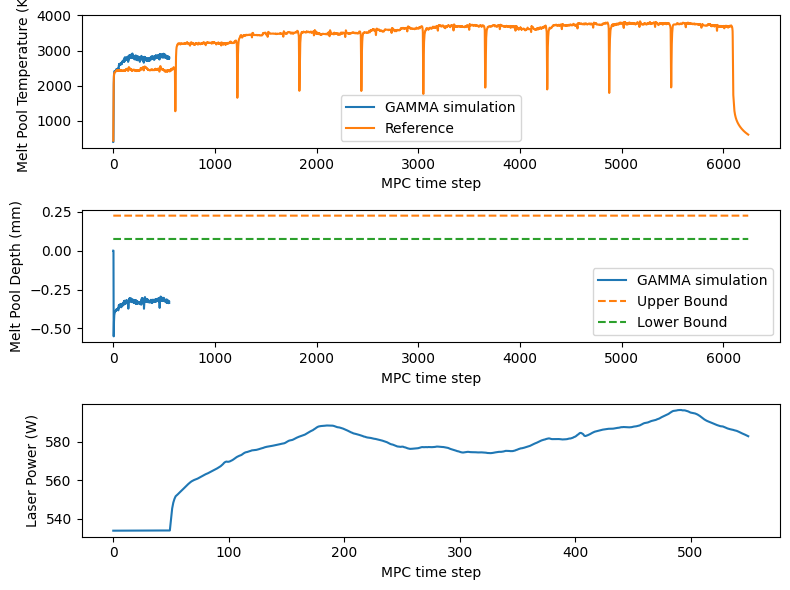

Laser 1:  16%|█▌        | 1000/6195 [01:56<10:08,  8.53it/s]

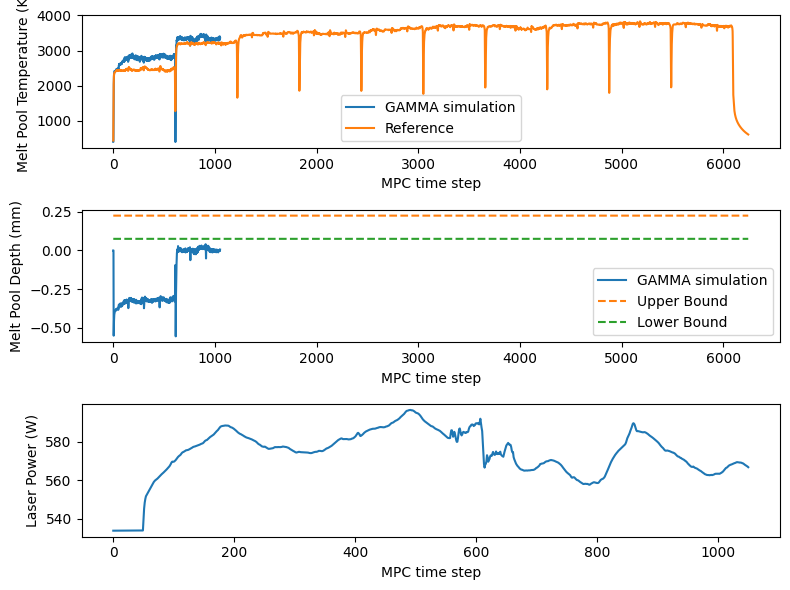

Laser 1:  24%|██▍       | 1500/6195 [02:57<09:40,  8.09it/s]

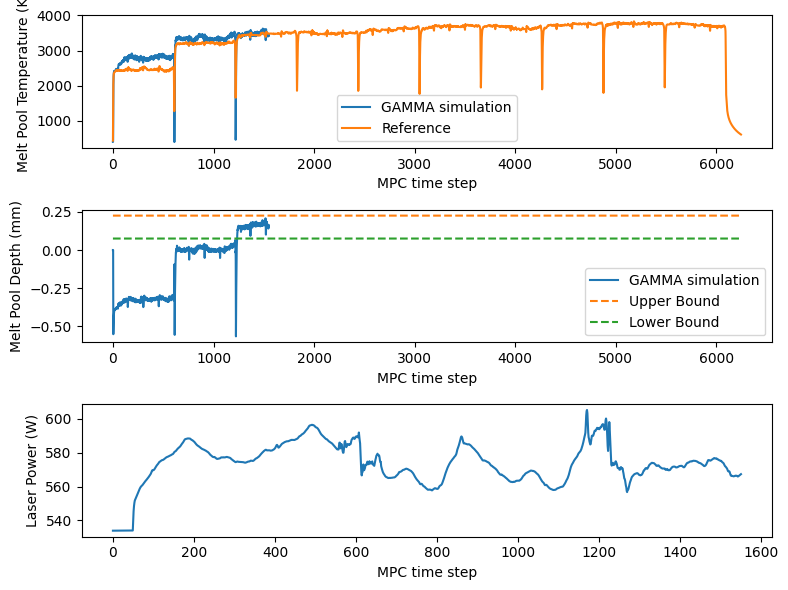

Laser 1:  32%|███▏      | 2000/6195 [04:00<08:49,  7.92it/s]

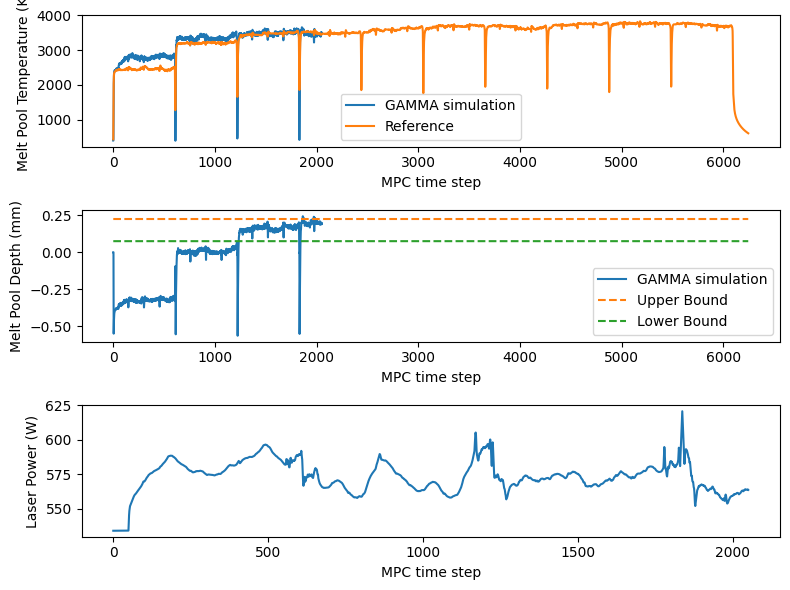

Laser 1:  40%|████      | 2500/6195 [05:05<08:02,  7.66it/s]

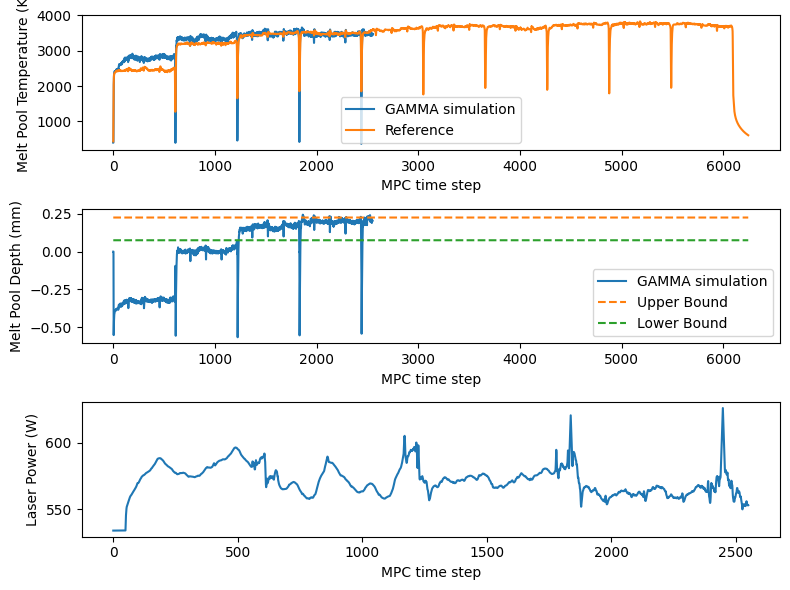

Laser 1:  48%|████▊     | 3000/6195 [06:11<06:25,  8.28it/s]

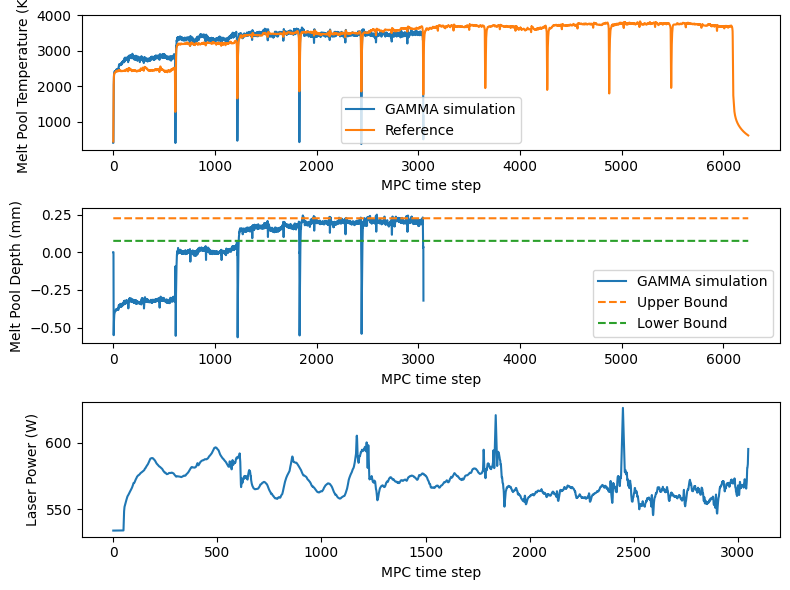

Laser 1:  56%|█████▋    | 3500/6195 [07:18<06:01,  7.46it/s]

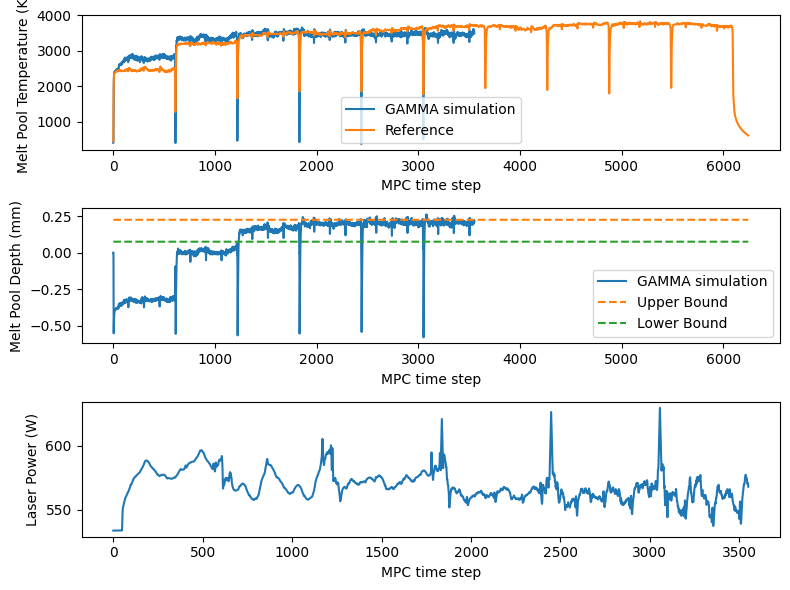

Laser 1:  65%|██████▍   | 4000/6195 [08:26<04:55,  7.42it/s]

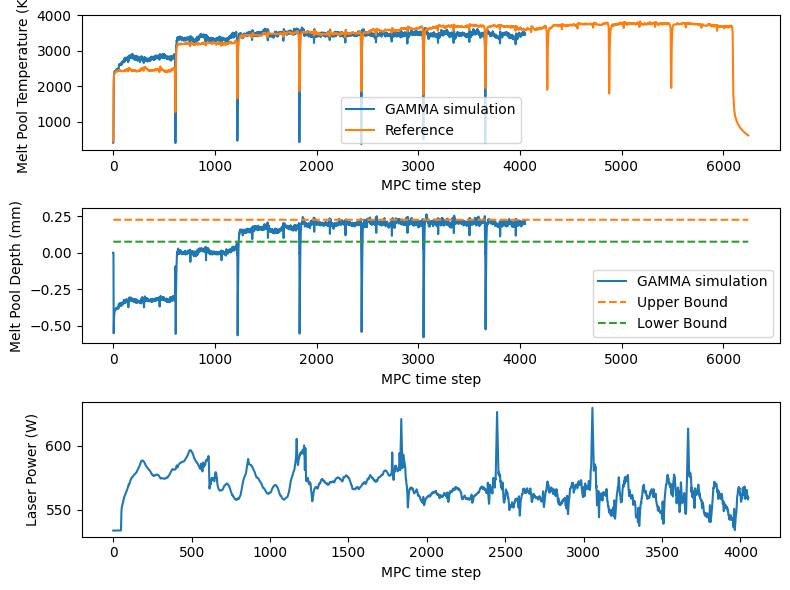

Laser 1:  73%|███████▎  | 4500/6195 [09:35<03:53,  7.25it/s]

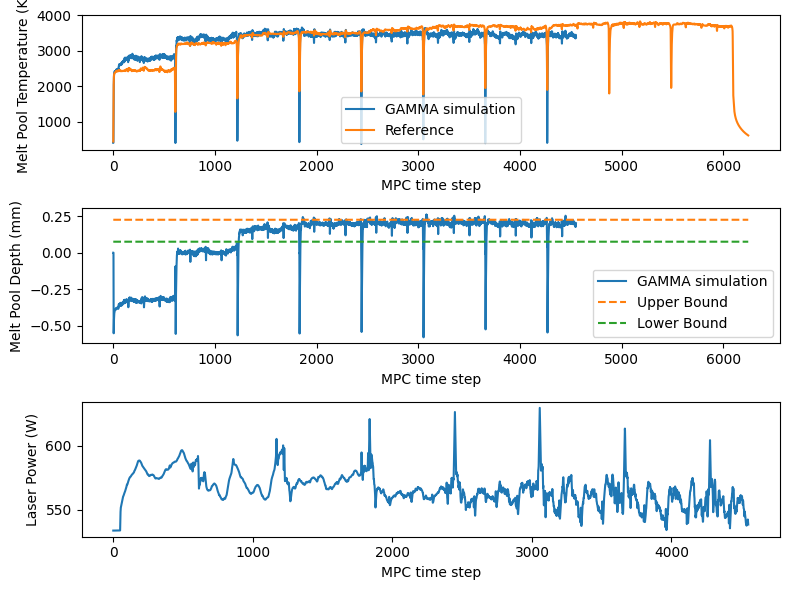

Laser 1:  81%|████████  | 5000/6195 [10:45<02:49,  7.04it/s]

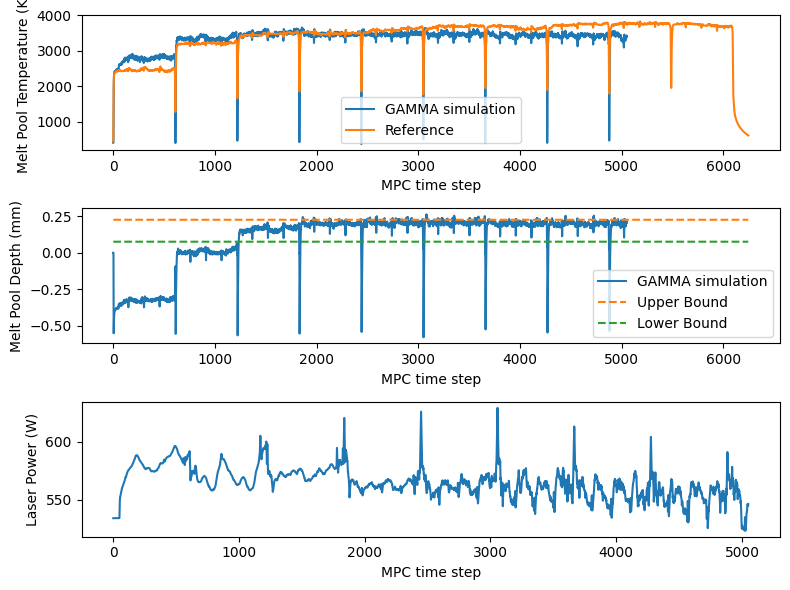

Laser 1:  89%|████████▉ | 5500/6195 [11:56<01:39,  7.00it/s]

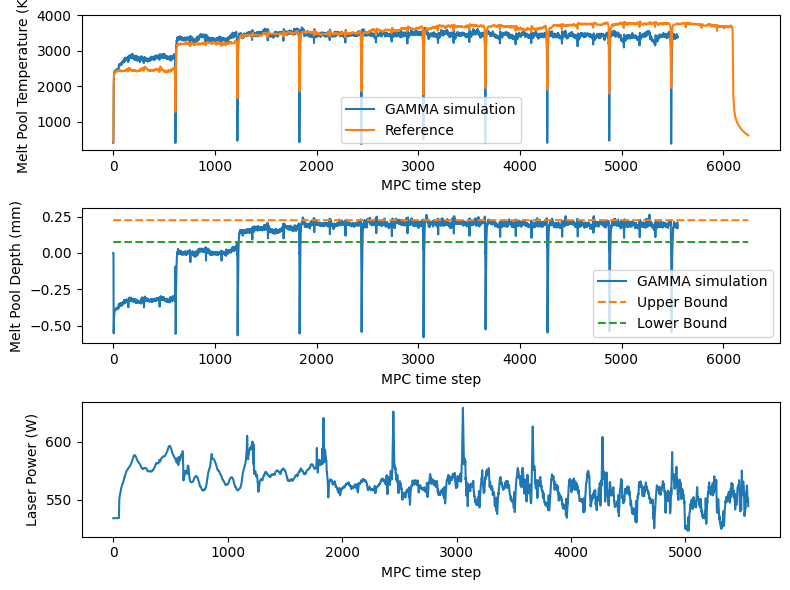

Laser 1:  97%|█████████▋| 6000/6195 [13:09<00:28,  6.93it/s]

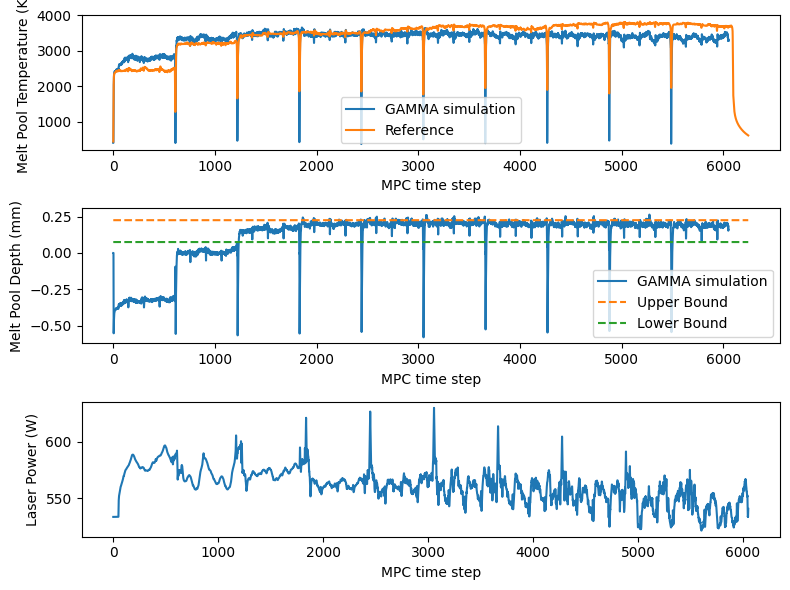

Laser 1: 100%|██████████| 6195/6195 [13:35<00:00,  7.60it/s]


Saved plot to /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/time/addnoise/policy_roll_epoch0099.pth_clamped(1)/final_plot_laser_1.png
              Time
count  6195.000000
mean      0.000603
std       0.000124
min       0.000535
25%       0.000570
50%       0.000581
75%       0.000600
max       0.004356
✅ Completed and saved for laser_power_number 1


In [14]:


# ── Constants ─────────────────────────────────────
INPUT_DATA_DIR = "data"
SIM_DIR_NAME = "single_track_square"
BASE_LASER_FILE_DIR = "laser_power_profiles/csv"
CLOUD_TARGET_BASE_PATH = "result"
solidus_temp = 1600
window = 50
sim_interval = 5
init_runs = 50
P = 50

model_path = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/policy_roll_epoch0099.pth"

# ── Load model ─────────────────────────────────────
ckpt = torch.load(model_path, map_location=device)
model = PolicyNN(
    past_input_dim=6,
    future_input_dim=6,
    output_dim=1,
    p=P,
    window=window,
    hidden_dim=1024,
    n_layers=3,
    dropout_p=0.0
).to(device)

state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)

#ckpt = torch.load(model_path)
#model.load_state_dict(ckpt["model_state_dict"])


model.eval()

# ── Output directory ───────────────────────────────
save_dir = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/time/addnoise/policy_roll_epoch0099.pth_clamped(1)"
os.makedirs(save_dir, exist_ok=True)

# ── Loop over laser_power_number 2 to 30 ───────────
for laser_num in range(1,2):
    try:
        # Step 1: Load input CSV
        csv_path = f"/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/split_by_laser_power_number/laser_power_number_{laser_num}.csv"
        df = pd.read_csv(csv_path)

        # Step 2: Instantiate GAMMA class
        GAMMA_class = GAMMA_obj(INPUT_DATA_DIR, SIM_DIR_NAME, BASE_LASER_FILE_DIR,
                                CLOUD_TARGET_BASE_PATH, solidus_temp, window,
                                init_runs, sim_interval, laser_power_number=laser_num)

        # Step 3: Run initial steps
        init_avg = GAMMA_class.run_initial_steps()
        init_avg = torch.tensor(init_avg, dtype=torch.float32).to(device)[:, -window:]

        # Step 4: Prepare inputs
        loc_Z = df["Z"].to_numpy().reshape(-1, 1)
        dist_X = df["Dist_to_nearest_X"].to_numpy().reshape(-1, 1)
        dist_Y = df["Dist_to_nearest_Y"].to_numpy().reshape(-1, 1)
        fix_covariates = torch.tensor(np.concatenate((loc_Z, dist_X, dist_Y), axis=1), dtype=torch.float32).to(device)

        laser_power_ref = torch.tensor(df["Laser_power"].to_numpy().reshape(-1, 1), dtype=torch.float32).to(device)
        laser_power_past = laser_power_ref[:window]

        mp_temp_raw = df["melt_pool_temperature"].to_numpy()
        mp_temp = copy.deepcopy(mp_temp_raw)
        mp_temp[1:-2] = moving_average_1d(mp_temp_raw, 4)
        mp_temp_ref = torch.tensor(mp_temp, dtype=torch.float32).to(device)

        # ---- depth는 있으면 만들고, 없으면 스킵 ----
        if "melt_pool_depth" in df.columns:
            mp_depth_raw = df["melt_pool_depth"].to_numpy()
            mp_depth = copy.deepcopy(mp_depth_raw)
            mp_depth[1:-2] = moving_average_1d(mp_depth_raw, 4)
            mp_depth_ref = torch.tensor(mp_depth, dtype=torch.float32).to(device)
        else:
            mp_depth_ref = None
            print(f"[WARN] laser {laser_num}: 'melt_pool_depth' column not found -> skip depth.")


        # Step 5: Initialize GAMMA_class variables
        GAMMA_class.ref = mp_temp_ref.clone().to(device)
        GAMMA_class.fix_cov_all = fix_covariates.clone().to(device)
        GAMMA_class.x_past = init_avg.clone().to(device)
        GAMMA_class.u_past = laser_power_past.clone().to(device)
        GAMMA_class.x_past_save = GAMMA_class.x_past.T.clone().to(device)
        GAMMA_class.u_past_save = GAMMA_class.u_past.clone().to(device)
        GAMMA_class.MPC_counter = window
        GAMMA_class.x_hat_current = GAMMA_class.x_past[:, -1].to(device)
        GAMMA_class.x_sys_current = GAMMA_class.x_past[:, -1].reshape(2, 1).to(device)
        GAMMA_class.save_time = []

        # 측정 노이즈용 RNG (laser별 seed 분리 → 재현 가능)
        GAMMA_class.meas_rng = np.random.default_rng(NOISE_SEED_BASE + laser_num)
        # (선택) ground truth 저장 버퍼 — x_past_save와 동일하게 시작
        GAMMA_class.x_true_save = GAMMA_class.x_past_save.clone()

        print(f"[DEBUG] laser {laser_num} save types:")
        print("  x_past_save:", type(GAMMA_class.x_past_save))
        print("  u_past_save:", type(GAMMA_class.u_past_save))
        print("  ref:", type(GAMMA_class.ref))


        # Step 6: Run simulation loop
        N_step = len(mp_temp_ref) - P
        for i in tqdm(range(N_step - P), desc=f"Laser {laser_num}"):
            run_one_step_policy(GAMMA_class, model, P=P, window=window)
            if i % 500 == 0:
                plot_fig(GAMMA_class, N_step)   # ✅ 중간 출력(화면) 그대로

        # ✅ 최종 플롯만 save_dir에 저장
        final_plot_path = os.path.join(save_dir, f"final_plot_laser_{laser_num}.png")
        plot_fig(GAMMA_class, N_step, save_path=final_plot_path)

        # Step 7: Save outputs
        x_save = GAMMA_class.x_past_save.detach().cpu().numpy()
        u_save = GAMMA_class.u_past_save.detach().cpu().numpy()
        ref_save = GAMMA_class.ref.detach().cpu().numpy()

        # ✅ 시간 저장
        df_time = pd.DataFrame({'Time': GAMMA_class.save_time})
        print(df_time.describe())  # 평균/min/max 바로 확인
        df_time.to_csv(
            os.path.join(save_dir, f"policy_time_laser_{laser_num}.csv"), index=False)

        pd.DataFrame(x_save).to_csv(
            os.path.join(save_dir, f"x_outputs_laser_{laser_num}.csv"), index=False)
        pd.DataFrame(u_save).to_csv(
            os.path.join(save_dir, f"u_outputs_laser_{laser_num}.csv"), index=False)
        pd.DataFrame(ref_save).to_csv(
            os.path.join(save_dir, f"ref_laser_{laser_num}.csv"), index=False)
        # (선택) ground truth 저장
        if hasattr(GAMMA_class, "x_true_save"):
            xtrue_save = GAMMA_class.x_true_save.detach().cpu().numpy()
            pd.DataFrame(xtrue_save).to_csv(
                os.path.join(save_dir, f"x_true_outputs_laser_{laser_num}.csv"), index=False)


        print(f"✅ Completed and saved for laser_power_number {laser_num}")

    except Exception as e:
        print(f"❌ Error in laser_power_number {laser_num}: {e}")


100%|██████████| 250/250 [00:05<00:00, 45.99it/s]


[WARN] laser 1: 'melt_pool_depth' column not found -> skip depth.
[DEBUG] laser 1 save types:
  x_past_save: <class 'torch.Tensor'>
  u_past_save: <class 'torch.Tensor'>
  ref: <class 'torch.Tensor'>


Laser 1:   0%|          | 0/6195 [00:00<?, ?it/s]

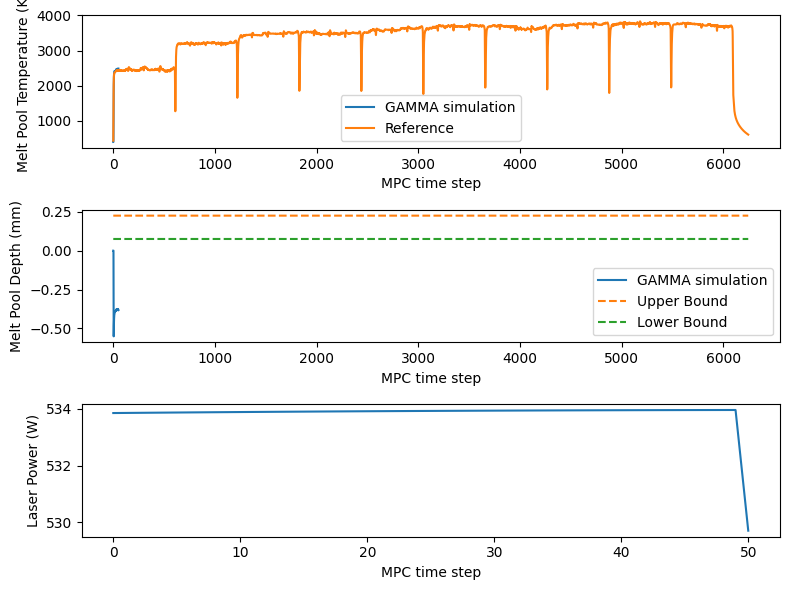

Laser 1:   7%|▋         | 464/6195 [00:52<10:56,  8.73it/s]

Laser 1:   8%|▊         | 500/6195 [00:57<10:53,  8.71it/s]

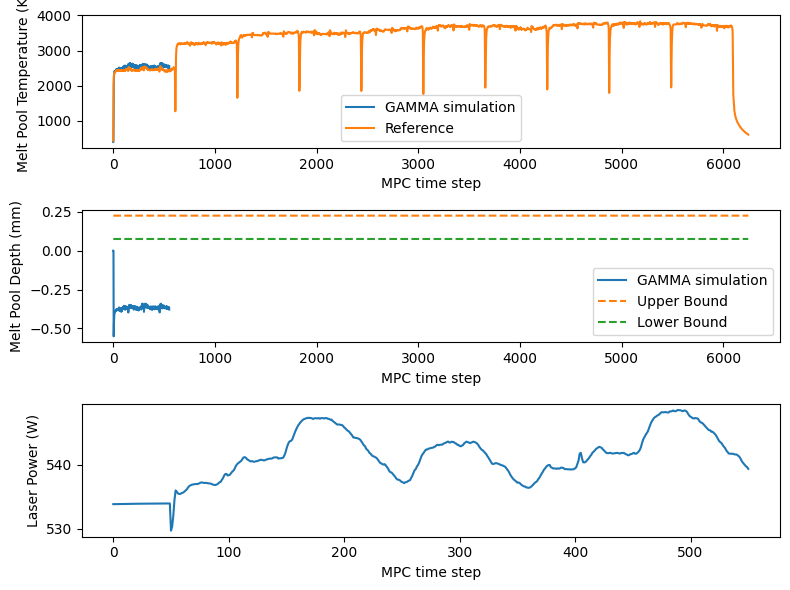

Laser 1:  16%|█▌        | 1000/6195 [01:56<10:18,  8.40it/s]

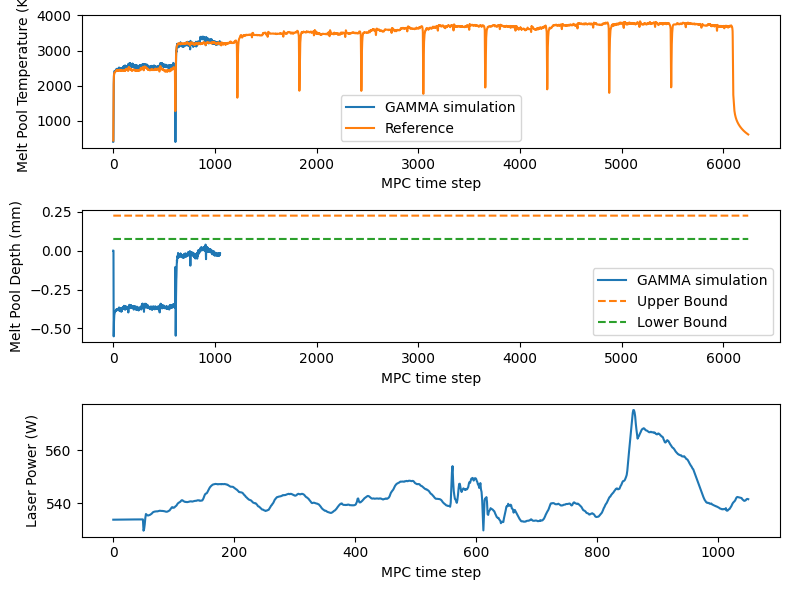

Laser 1:  24%|██▍       | 1500/6195 [02:57<09:42,  8.07it/s]

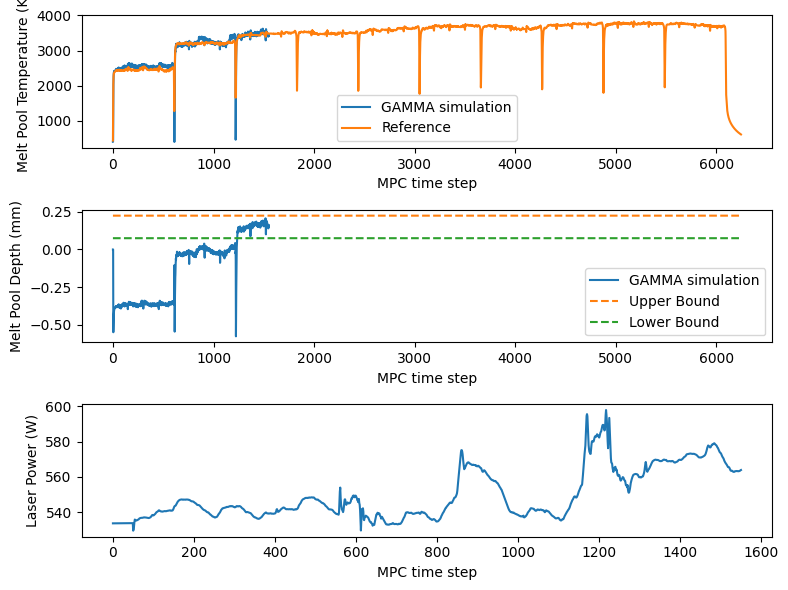

Laser 1:  32%|███▏      | 2000/6195 [04:00<08:57,  7.81it/s]

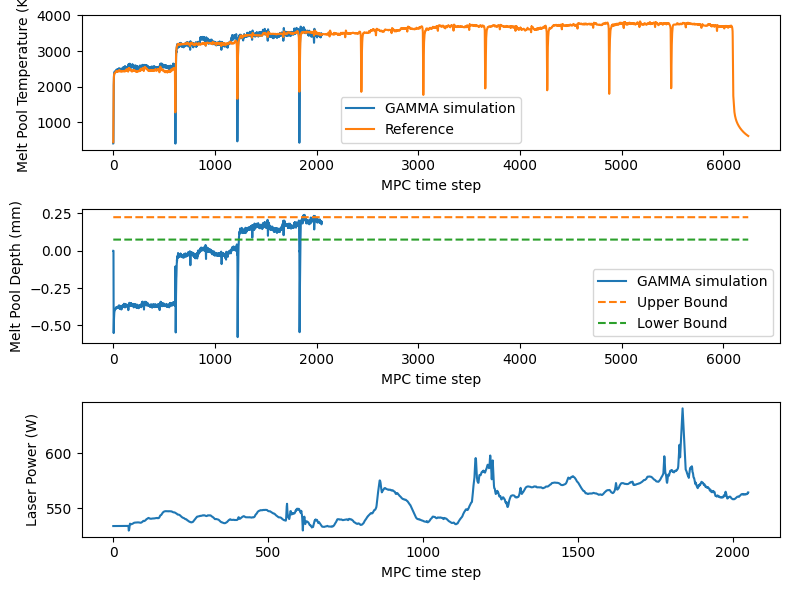

Laser 1:  40%|████      | 2500/6195 [05:05<08:09,  7.56it/s]

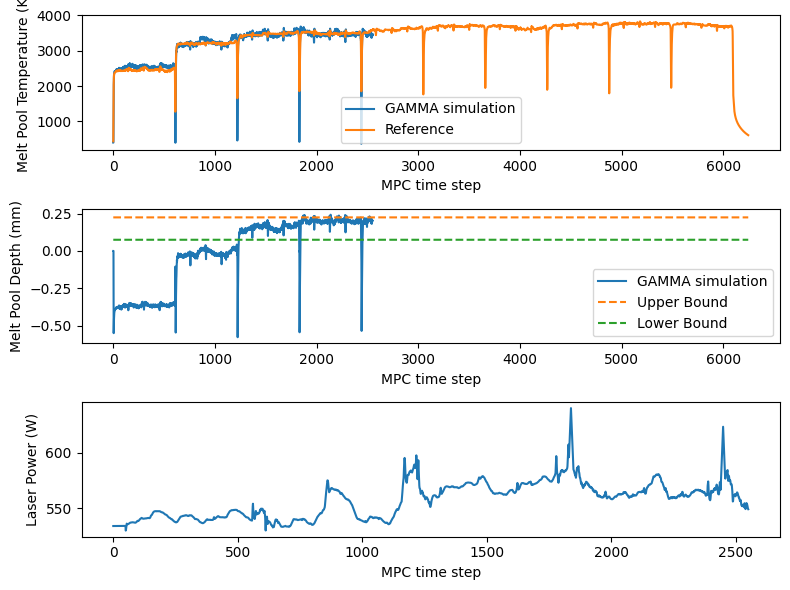

Laser 1:  48%|████▊     | 3000/6195 [06:12<06:26,  8.26it/s]

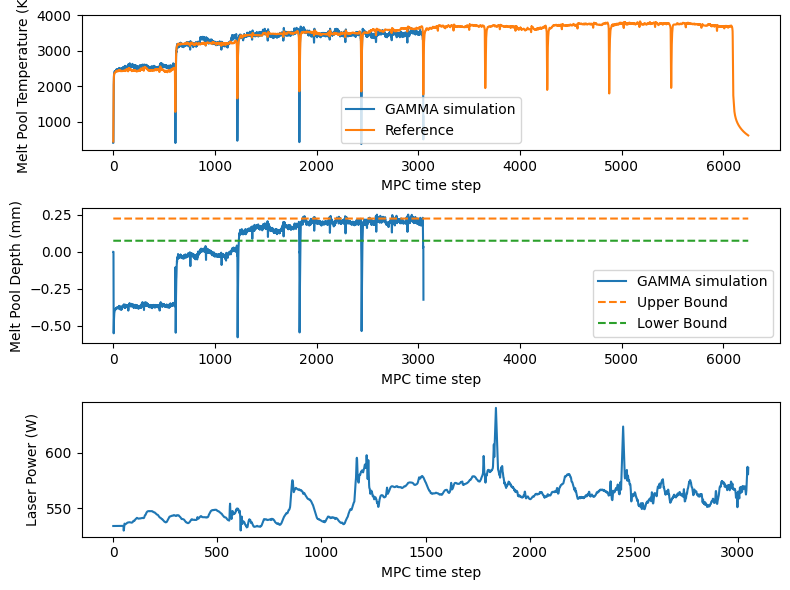

Laser 1:  56%|█████▋    | 3500/6195 [07:19<05:59,  7.49it/s]

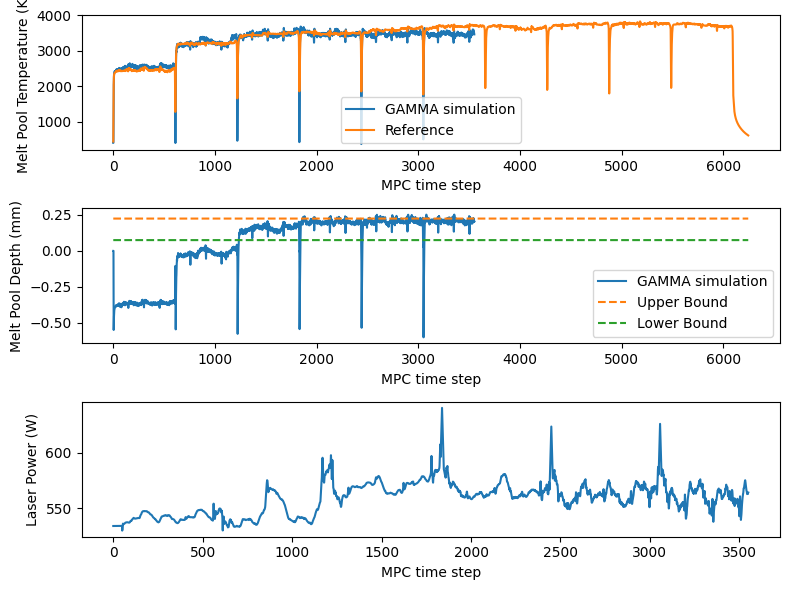

Laser 1:  65%|██████▍   | 4000/6195 [08:27<04:54,  7.45it/s]

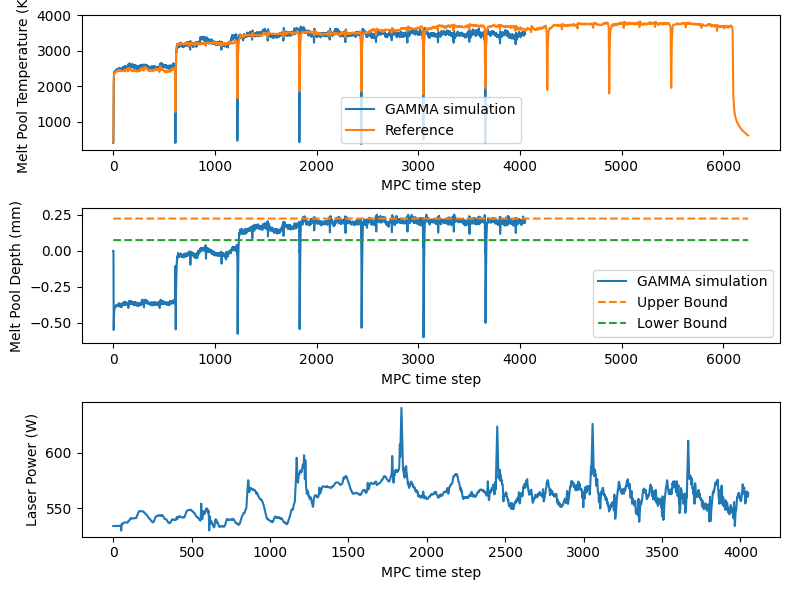

Laser 1:  73%|███████▎  | 4500/6195 [09:35<03:52,  7.28it/s]

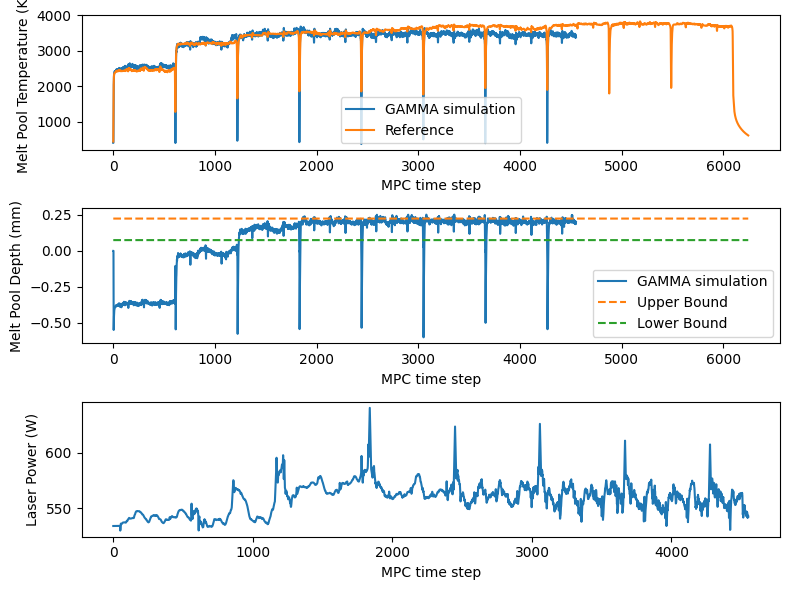

Laser 1:  81%|████████  | 5000/6195 [10:45<02:48,  7.11it/s]

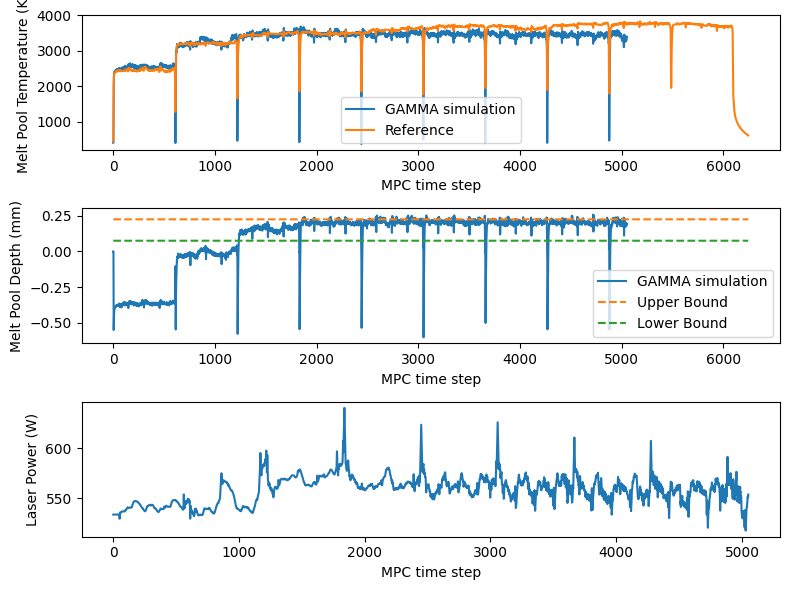

Laser 1:  89%|████████▉ | 5500/6195 [11:56<01:38,  7.03it/s]

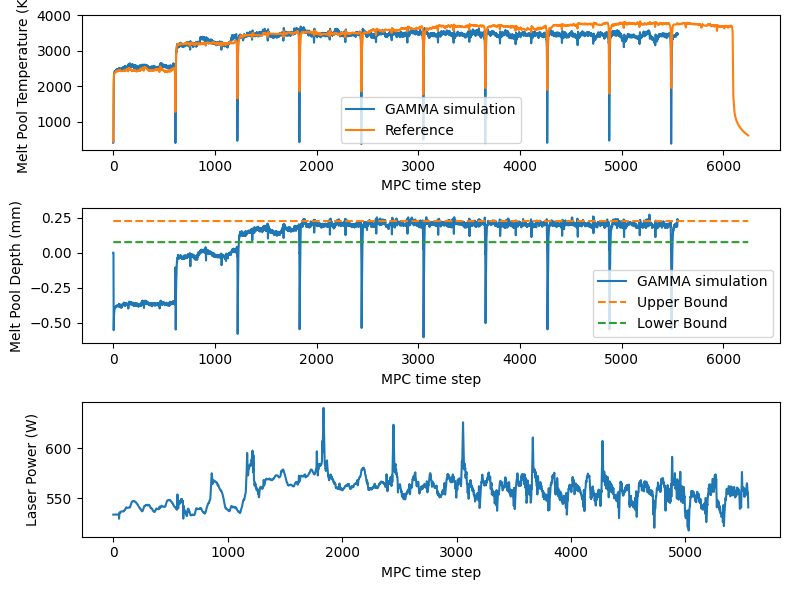

Laser 1:  97%|█████████▋| 6000/6195 [13:09<00:28,  6.93it/s]

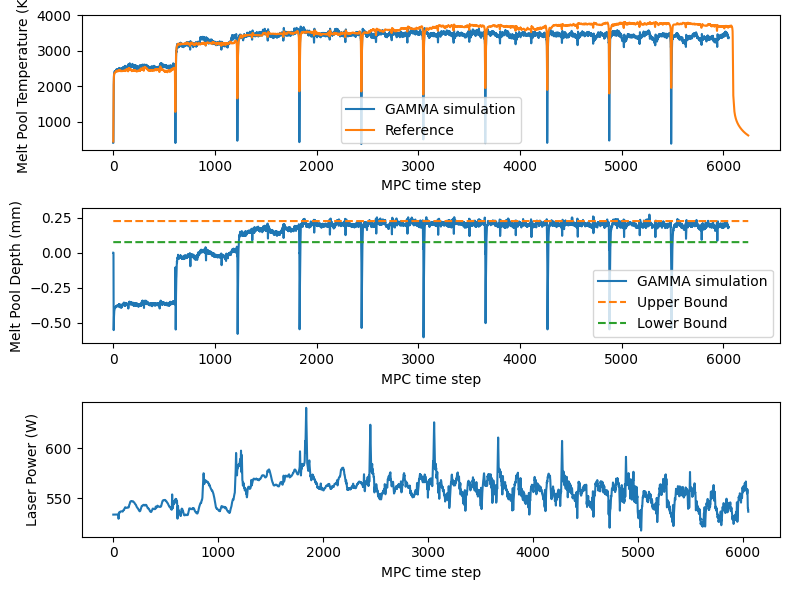

Laser 1: 100%|██████████| 6195/6195 [13:36<00:00,  7.59it/s]


Saved plot to /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/time/addnoise/policy_roll_epoch0149.pth_clamped(1)/final_plot_laser_1.png
              Time
count  6195.000000
mean      0.000588
std       0.000109
min       0.000511
25%       0.000549
50%       0.000566
75%       0.000587
max       0.001888
✅ Completed and saved for laser_power_number 1


In [15]:


# ── Constants ─────────────────────────────────────
INPUT_DATA_DIR = "data"
SIM_DIR_NAME = "single_track_square"
BASE_LASER_FILE_DIR = "laser_power_profiles/csv"
CLOUD_TARGET_BASE_PATH = "result"
solidus_temp = 1600
window = 50
sim_interval = 5
init_runs = 50
P = 50

model_path = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/policy_roll_epoch0149.pth"

# ── Load model ─────────────────────────────────────
ckpt = torch.load(model_path, map_location=device)
model = PolicyNN(
    past_input_dim=6,
    future_input_dim=6,
    output_dim=1,
    p=P,
    window=window,
    hidden_dim=1024,
    n_layers=3,
    dropout_p=0.0
).to(device)

state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)

#ckpt = torch.load(model_path)
#model.load_state_dict(ckpt["model_state_dict"])


model.eval()

# ── Output directory ───────────────────────────────
save_dir = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/time/addnoise/policy_roll_epoch0149.pth_clamped(1)"
os.makedirs(save_dir, exist_ok=True)

# ── Loop over laser_power_number 2 to 30 ───────────
for laser_num in range(1,2):
    try:
        # Step 1: Load input CSV
        csv_path = f"/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/split_by_laser_power_number/laser_power_number_{laser_num}.csv"
        df = pd.read_csv(csv_path)

        # Step 2: Instantiate GAMMA class
        GAMMA_class = GAMMA_obj(INPUT_DATA_DIR, SIM_DIR_NAME, BASE_LASER_FILE_DIR,
                                CLOUD_TARGET_BASE_PATH, solidus_temp, window,
                                init_runs, sim_interval, laser_power_number=laser_num)

        # Step 3: Run initial steps
        init_avg = GAMMA_class.run_initial_steps()
        init_avg = torch.tensor(init_avg, dtype=torch.float32).to(device)[:, -window:]

        # Step 4: Prepare inputs
        loc_Z = df["Z"].to_numpy().reshape(-1, 1)
        dist_X = df["Dist_to_nearest_X"].to_numpy().reshape(-1, 1)
        dist_Y = df["Dist_to_nearest_Y"].to_numpy().reshape(-1, 1)
        fix_covariates = torch.tensor(np.concatenate((loc_Z, dist_X, dist_Y), axis=1), dtype=torch.float32).to(device)

        laser_power_ref = torch.tensor(df["Laser_power"].to_numpy().reshape(-1, 1), dtype=torch.float32).to(device)
        laser_power_past = laser_power_ref[:window]

        mp_temp_raw = df["melt_pool_temperature"].to_numpy()
        mp_temp = copy.deepcopy(mp_temp_raw)
        mp_temp[1:-2] = moving_average_1d(mp_temp_raw, 4)
        mp_temp_ref = torch.tensor(mp_temp, dtype=torch.float32).to(device)

        # ---- depth는 있으면 만들고, 없으면 스킵 ----
        if "melt_pool_depth" in df.columns:
            mp_depth_raw = df["melt_pool_depth"].to_numpy()
            mp_depth = copy.deepcopy(mp_depth_raw)
            mp_depth[1:-2] = moving_average_1d(mp_depth_raw, 4)
            mp_depth_ref = torch.tensor(mp_depth, dtype=torch.float32).to(device)
        else:
            mp_depth_ref = None
            print(f"[WARN] laser {laser_num}: 'melt_pool_depth' column not found -> skip depth.")


        # Step 5: Initialize GAMMA_class variables
        GAMMA_class.ref = mp_temp_ref.clone().to(device)
        GAMMA_class.fix_cov_all = fix_covariates.clone().to(device)
        GAMMA_class.x_past = init_avg.clone().to(device)
        GAMMA_class.u_past = laser_power_past.clone().to(device)
        GAMMA_class.x_past_save = GAMMA_class.x_past.T.clone().to(device)
        GAMMA_class.u_past_save = GAMMA_class.u_past.clone().to(device)
        GAMMA_class.MPC_counter = window
        GAMMA_class.x_hat_current = GAMMA_class.x_past[:, -1].to(device)
        GAMMA_class.x_sys_current = GAMMA_class.x_past[:, -1].reshape(2, 1).to(device)
        GAMMA_class.save_time = []

        # 측정 노이즈용 RNG (laser별 seed 분리 → 재현 가능)
        GAMMA_class.meas_rng = np.random.default_rng(NOISE_SEED_BASE + laser_num)
        # (선택) ground truth 저장 버퍼 — x_past_save와 동일하게 시작
        GAMMA_class.x_true_save = GAMMA_class.x_past_save.clone()

        print(f"[DEBUG] laser {laser_num} save types:")
        print("  x_past_save:", type(GAMMA_class.x_past_save))
        print("  u_past_save:", type(GAMMA_class.u_past_save))
        print("  ref:", type(GAMMA_class.ref))


        # Step 6: Run simulation loop
        N_step = len(mp_temp_ref) - P
        for i in tqdm(range(N_step - P), desc=f"Laser {laser_num}"):
            run_one_step_policy(GAMMA_class, model, P=P, window=window)
            if i % 500 == 0:
                plot_fig(GAMMA_class, N_step)   # ✅ 중간 출력(화면) 그대로

        # ✅ 최종 플롯만 save_dir에 저장
        final_plot_path = os.path.join(save_dir, f"final_plot_laser_{laser_num}.png")
        plot_fig(GAMMA_class, N_step, save_path=final_plot_path)

        # Step 7: Save outputs
        x_save = GAMMA_class.x_past_save.detach().cpu().numpy()
        u_save = GAMMA_class.u_past_save.detach().cpu().numpy()
        ref_save = GAMMA_class.ref.detach().cpu().numpy()

        # ✅ 시간 저장
        df_time = pd.DataFrame({'Time': GAMMA_class.save_time})
        print(df_time.describe())  # 평균/min/max 바로 확인
        df_time.to_csv(
            os.path.join(save_dir, f"policy_time_laser_{laser_num}.csv"), index=False)

        pd.DataFrame(x_save).to_csv(
            os.path.join(save_dir, f"x_outputs_laser_{laser_num}.csv"), index=False)
        pd.DataFrame(u_save).to_csv(
            os.path.join(save_dir, f"u_outputs_laser_{laser_num}.csv"), index=False)
        pd.DataFrame(ref_save).to_csv(
            os.path.join(save_dir, f"ref_laser_{laser_num}.csv"), index=False)
        # (선택) ground truth 저장
        if hasattr(GAMMA_class, "x_true_save"):
            xtrue_save = GAMMA_class.x_true_save.detach().cpu().numpy()
            pd.DataFrame(xtrue_save).to_csv(
                os.path.join(save_dir, f"x_true_outputs_laser_{laser_num}.csv"), index=False)


        print(f"✅ Completed and saved for laser_power_number {laser_num}")

    except Exception as e:
        print(f"❌ Error in laser_power_number {laser_num}: {e}")


100%|██████████| 250/250 [00:05<00:00, 45.32it/s]


[WARN] laser 1: 'melt_pool_depth' column not found -> skip depth.
[DEBUG] laser 1 save types:
  x_past_save: <class 'torch.Tensor'>
  u_past_save: <class 'torch.Tensor'>
  ref: <class 'torch.Tensor'>


Laser 1:   0%|          | 0/6195 [00:00<?, ?it/s]

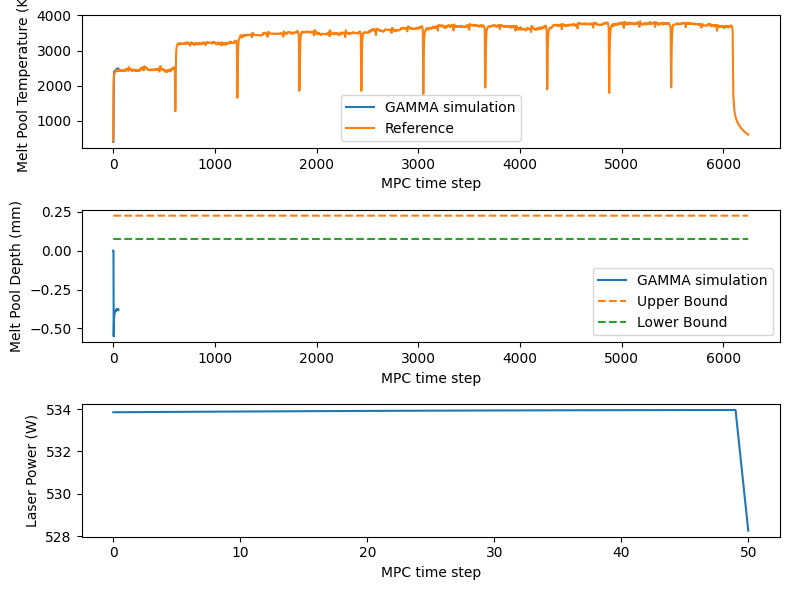

Laser 1:   8%|▊         | 500/6195 [00:57<10:59,  8.64it/s]

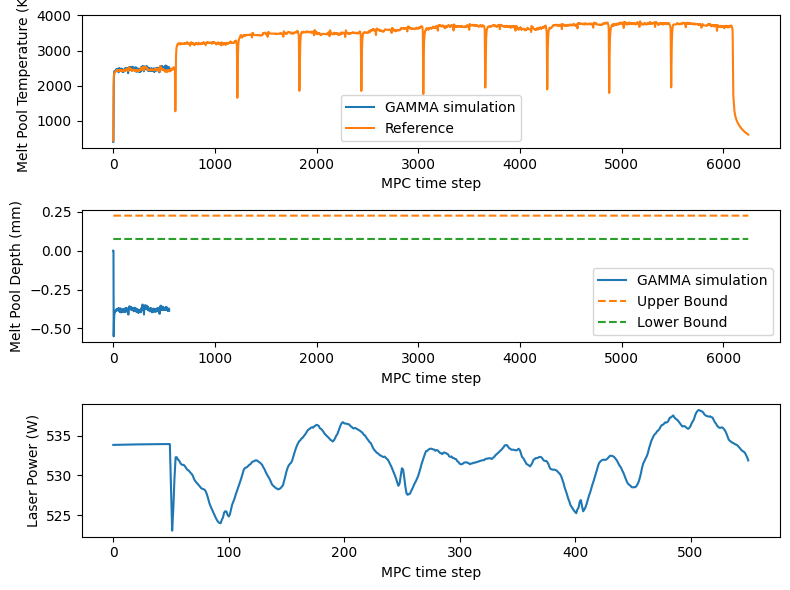

Laser 1:  16%|█▌        | 1000/6195 [01:57<10:10,  8.51it/s]

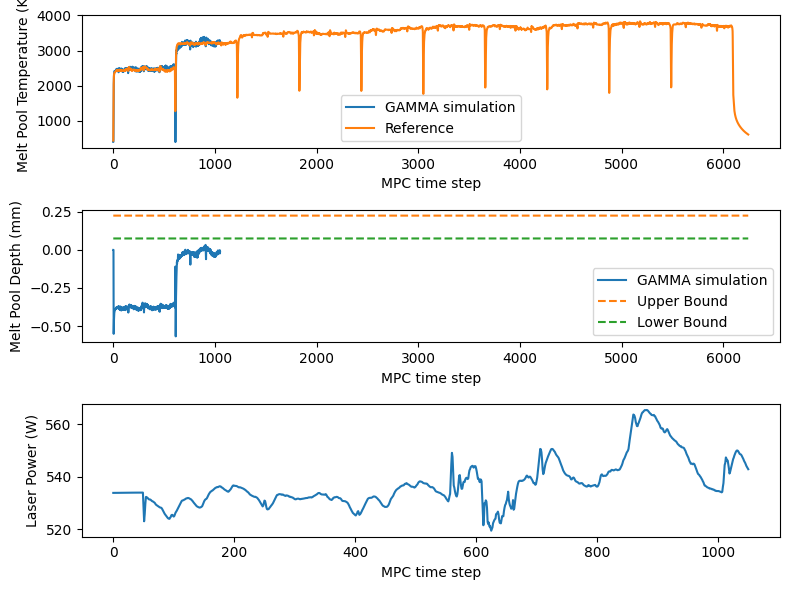

Laser 1:  24%|██▍       | 1500/6195 [02:58<09:48,  7.98it/s]

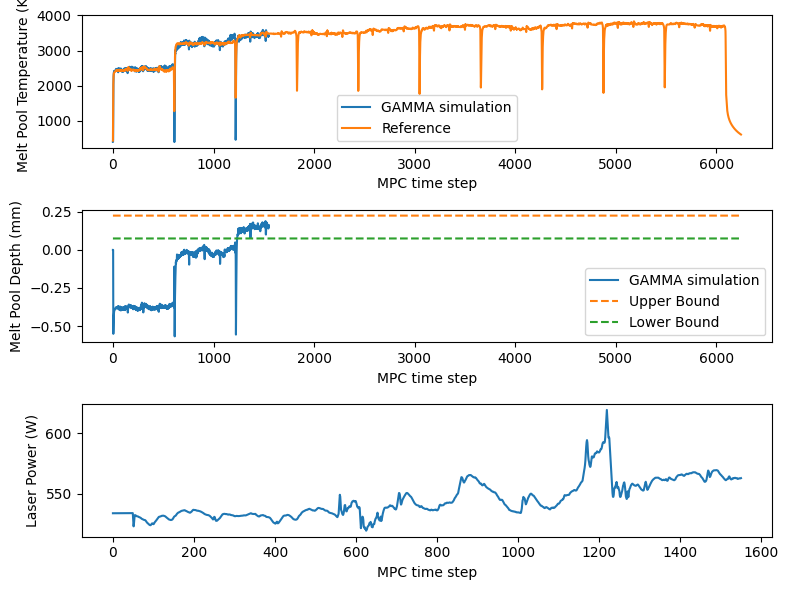

Laser 1:  32%|███▏      | 2000/6195 [04:02<08:50,  7.90it/s]

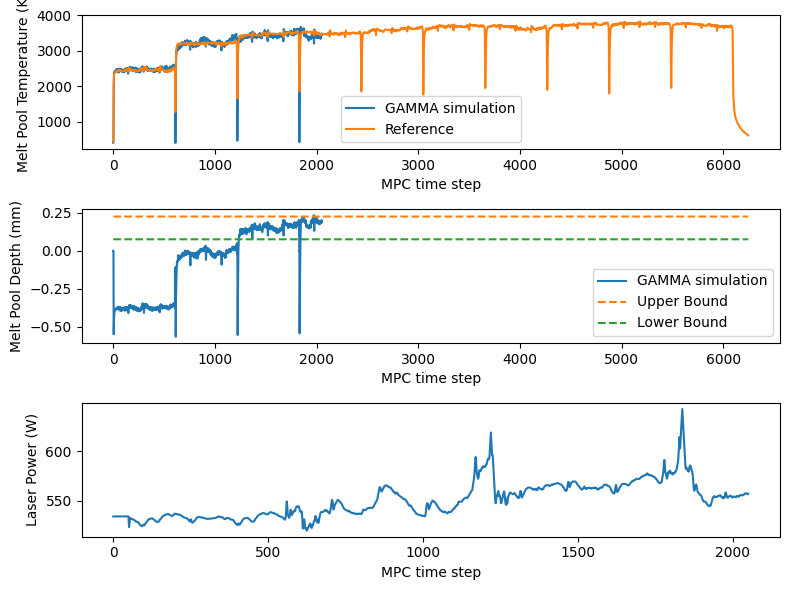

Laser 1:  40%|████      | 2500/6195 [05:07<08:08,  7.57it/s]

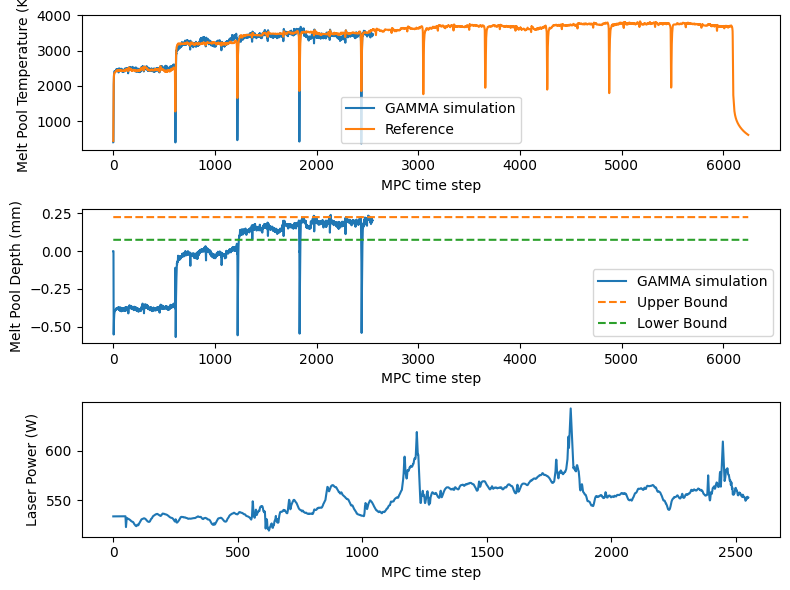

Laser 1:  48%|████▊     | 3000/6195 [06:13<06:25,  8.29it/s]

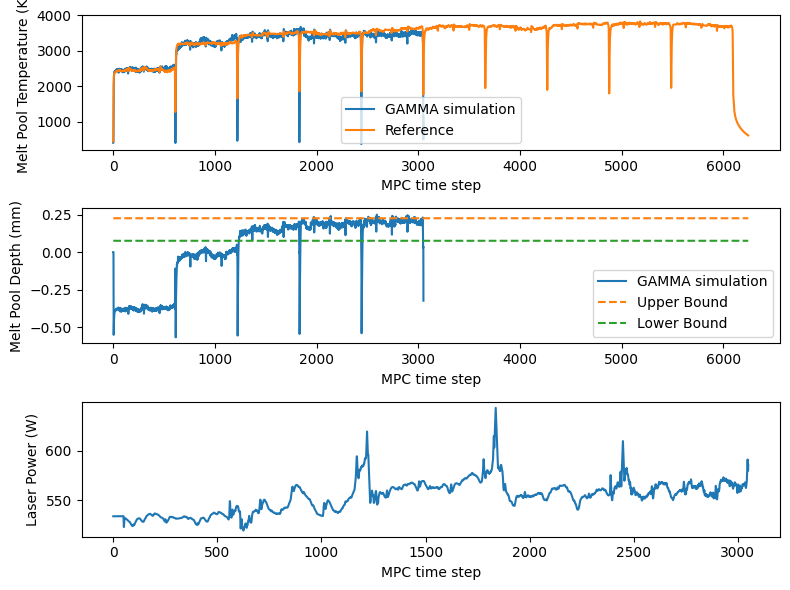

Laser 1:  56%|█████▋    | 3500/6195 [07:21<06:07,  7.33it/s]

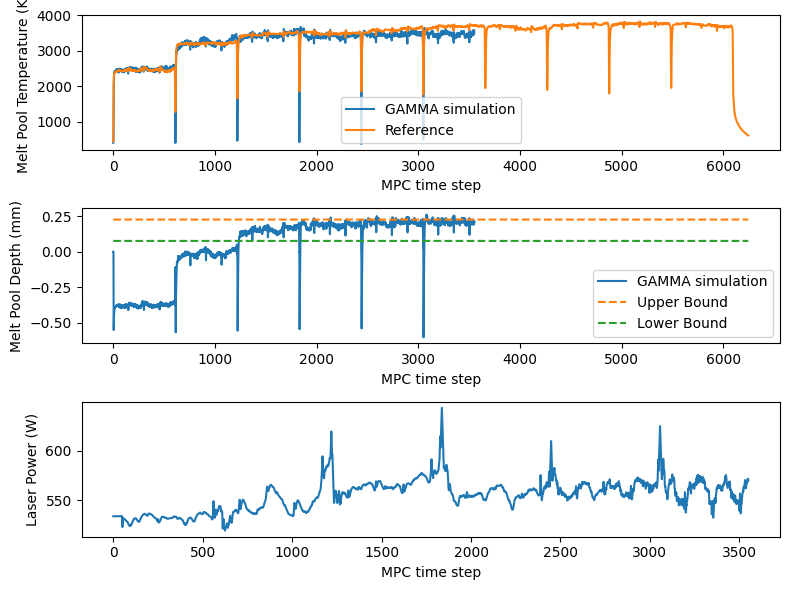

Laser 1:  65%|██████▍   | 4000/6195 [08:29<05:01,  7.29it/s]

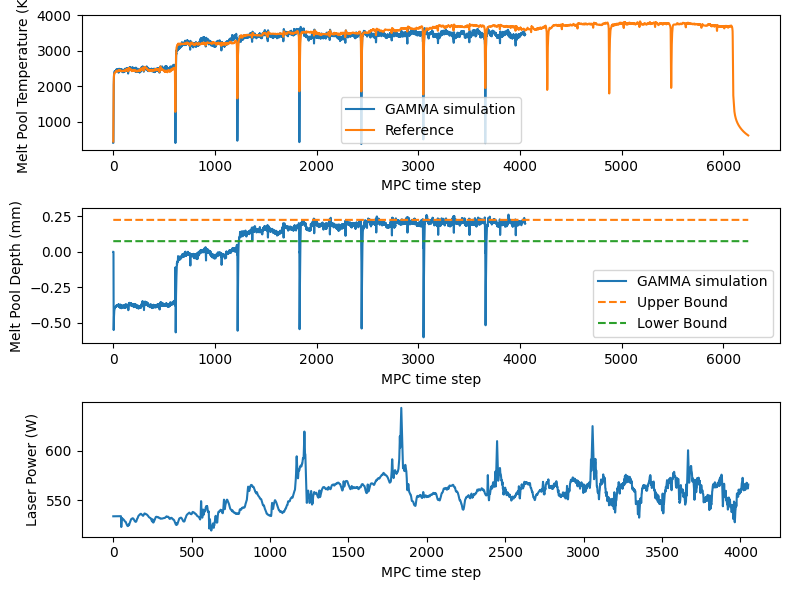

Laser 1:  73%|███████▎  | 4500/6195 [09:39<03:54,  7.22it/s]

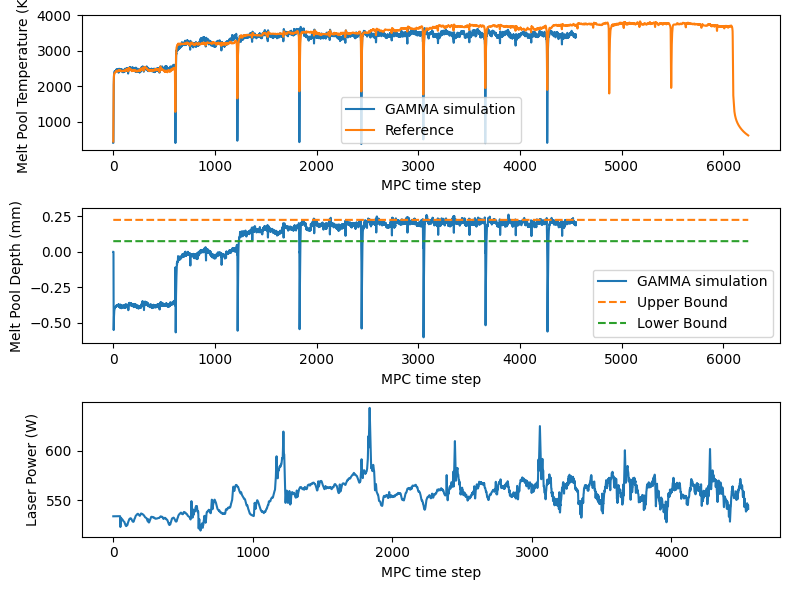

Laser 1:  81%|████████  | 5000/6195 [10:49<02:47,  7.15it/s]

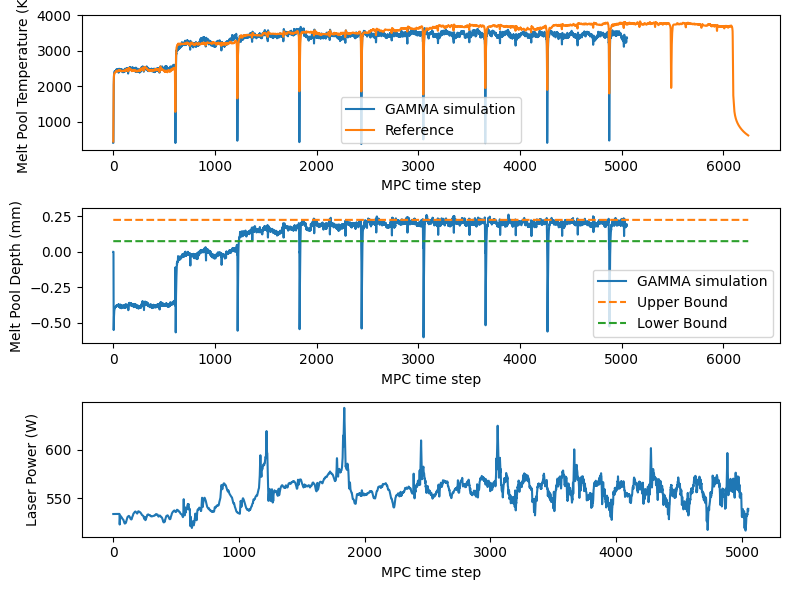

Laser 1:  89%|████████▉ | 5500/6195 [12:00<01:40,  6.93it/s]

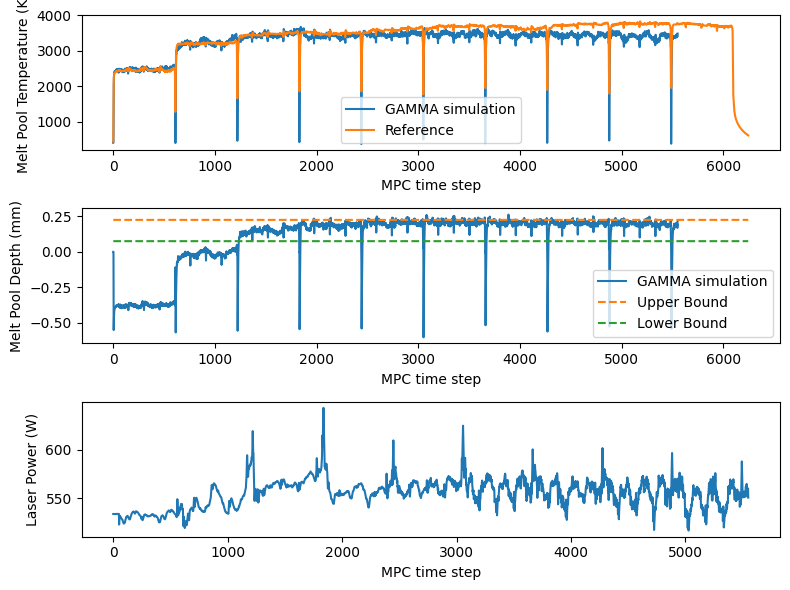

Laser 1:  97%|█████████▋| 6000/6195 [13:13<00:28,  6.96it/s]

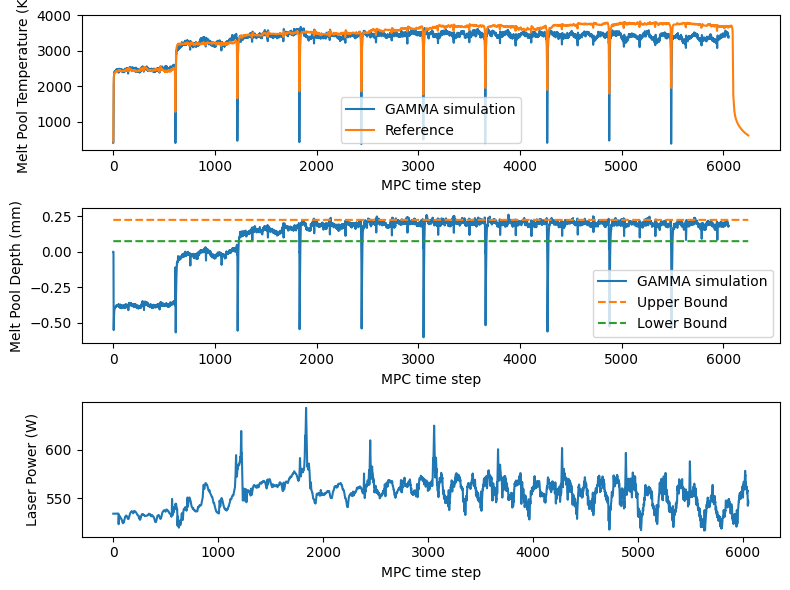

Laser 1: 100%|██████████| 6195/6195 [13:39<00:00,  7.56it/s]


Saved plot to /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/time/addnoise/policy_roll_epoch0249.pth_clamped(1)/final_plot_laser_1.png
              Time
count  6195.000000
mean      0.000612
std       0.000126
min       0.000539
25%       0.000569
50%       0.000582
75%       0.000604
max       0.001789
✅ Completed and saved for laser_power_number 1


In [16]:


# ── Constants ─────────────────────────────────────
INPUT_DATA_DIR = "data"
SIM_DIR_NAME = "single_track_square"
BASE_LASER_FILE_DIR = "laser_power_profiles/csv"
CLOUD_TARGET_BASE_PATH = "result"
solidus_temp = 1600
window = 50
sim_interval = 5
init_runs = 50
P = 50

model_path = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/policy_roll_epoch0249.pth"

# ── Load model ─────────────────────────────────────
ckpt = torch.load(model_path, map_location=device)
model = PolicyNN(
    past_input_dim=6,
    future_input_dim=6,
    output_dim=1,
    p=P,
    window=window,
    hidden_dim=1024,
    n_layers=3,
    dropout_p=0.0
).to(device)

state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)

#ckpt = torch.load(model_path)
#model.load_state_dict(ckpt["model_state_dict"])


model.eval()

# ── Output directory ───────────────────────────────
save_dir = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/time/addnoise/policy_roll_epoch0249.pth_clamped(1)"
os.makedirs(save_dir, exist_ok=True)

# ── Loop over laser_power_number 2 to 30 ───────────
for laser_num in range(1,2):
    try:
        # Step 1: Load input CSV
        csv_path = f"/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/split_by_laser_power_number/laser_power_number_{laser_num}.csv"
        df = pd.read_csv(csv_path)

        # Step 2: Instantiate GAMMA class
        GAMMA_class = GAMMA_obj(INPUT_DATA_DIR, SIM_DIR_NAME, BASE_LASER_FILE_DIR,
                                CLOUD_TARGET_BASE_PATH, solidus_temp, window,
                                init_runs, sim_interval, laser_power_number=laser_num)

        # Step 3: Run initial steps
        init_avg = GAMMA_class.run_initial_steps()
        init_avg = torch.tensor(init_avg, dtype=torch.float32).to(device)[:, -window:]

        # Step 4: Prepare inputs
        loc_Z = df["Z"].to_numpy().reshape(-1, 1)
        dist_X = df["Dist_to_nearest_X"].to_numpy().reshape(-1, 1)
        dist_Y = df["Dist_to_nearest_Y"].to_numpy().reshape(-1, 1)
        fix_covariates = torch.tensor(np.concatenate((loc_Z, dist_X, dist_Y), axis=1), dtype=torch.float32).to(device)

        laser_power_ref = torch.tensor(df["Laser_power"].to_numpy().reshape(-1, 1), dtype=torch.float32).to(device)
        laser_power_past = laser_power_ref[:window]

        mp_temp_raw = df["melt_pool_temperature"].to_numpy()
        mp_temp = copy.deepcopy(mp_temp_raw)
        mp_temp[1:-2] = moving_average_1d(mp_temp_raw, 4)
        mp_temp_ref = torch.tensor(mp_temp, dtype=torch.float32).to(device)

        # ---- depth는 있으면 만들고, 없으면 스킵 ----
        if "melt_pool_depth" in df.columns:
            mp_depth_raw = df["melt_pool_depth"].to_numpy()
            mp_depth = copy.deepcopy(mp_depth_raw)
            mp_depth[1:-2] = moving_average_1d(mp_depth_raw, 4)
            mp_depth_ref = torch.tensor(mp_depth, dtype=torch.float32).to(device)
        else:
            mp_depth_ref = None
            print(f"[WARN] laser {laser_num}: 'melt_pool_depth' column not found -> skip depth.")


        # Step 5: Initialize GAMMA_class variables
        GAMMA_class.ref = mp_temp_ref.clone().to(device)
        GAMMA_class.fix_cov_all = fix_covariates.clone().to(device)
        GAMMA_class.x_past = init_avg.clone().to(device)
        GAMMA_class.u_past = laser_power_past.clone().to(device)
        GAMMA_class.x_past_save = GAMMA_class.x_past.T.clone().to(device)
        GAMMA_class.u_past_save = GAMMA_class.u_past.clone().to(device)
        GAMMA_class.MPC_counter = window
        GAMMA_class.x_hat_current = GAMMA_class.x_past[:, -1].to(device)
        GAMMA_class.x_sys_current = GAMMA_class.x_past[:, -1].reshape(2, 1).to(device)
        GAMMA_class.save_time = []

        # 측정 노이즈용 RNG (laser별 seed 분리 → 재현 가능)
        GAMMA_class.meas_rng = np.random.default_rng(NOISE_SEED_BASE + laser_num)
        # (선택) ground truth 저장 버퍼 — x_past_save와 동일하게 시작
        GAMMA_class.x_true_save = GAMMA_class.x_past_save.clone()

        print(f"[DEBUG] laser {laser_num} save types:")
        print("  x_past_save:", type(GAMMA_class.x_past_save))
        print("  u_past_save:", type(GAMMA_class.u_past_save))
        print("  ref:", type(GAMMA_class.ref))


        # Step 6: Run simulation loop
        N_step = len(mp_temp_ref) - P
        for i in tqdm(range(N_step - P), desc=f"Laser {laser_num}"):
            run_one_step_policy(GAMMA_class, model, P=P, window=window)
            if i % 500 == 0:
                plot_fig(GAMMA_class, N_step)   # ✅ 중간 출력(화면) 그대로

        # ✅ 최종 플롯만 save_dir에 저장
        final_plot_path = os.path.join(save_dir, f"final_plot_laser_{laser_num}.png")
        plot_fig(GAMMA_class, N_step, save_path=final_plot_path)

        # Step 7: Save outputs
        x_save = GAMMA_class.x_past_save.detach().cpu().numpy()
        u_save = GAMMA_class.u_past_save.detach().cpu().numpy()
        ref_save = GAMMA_class.ref.detach().cpu().numpy()

        # ✅ 시간 저장
        df_time = pd.DataFrame({'Time': GAMMA_class.save_time})
        print(df_time.describe())  # 평균/min/max 바로 확인
        df_time.to_csv(
            os.path.join(save_dir, f"policy_time_laser_{laser_num}.csv"), index=False)

        pd.DataFrame(x_save).to_csv(
            os.path.join(save_dir, f"x_outputs_laser_{laser_num}.csv"), index=False)
        pd.DataFrame(u_save).to_csv(
            os.path.join(save_dir, f"u_outputs_laser_{laser_num}.csv"), index=False)
        pd.DataFrame(ref_save).to_csv(
            os.path.join(save_dir, f"ref_laser_{laser_num}.csv"), index=False)
        # (선택) ground truth 저장
        if hasattr(GAMMA_class, "x_true_save"):
            xtrue_save = GAMMA_class.x_true_save.detach().cpu().numpy()
            pd.DataFrame(xtrue_save).to_csv(
                os.path.join(save_dir, f"x_true_outputs_laser_{laser_num}.csv"), index=False)


        print(f"✅ Completed and saved for laser_power_number {laser_num}")

    except Exception as e:
        print(f"❌ Error in laser_power_number {laser_num}: {e}")


100%|██████████| 250/250 [00:05<00:00, 45.95it/s]


[WARN] laser 1: 'melt_pool_depth' column not found -> skip depth.
[DEBUG] laser 1 save types:
  x_past_save: <class 'torch.Tensor'>
  u_past_save: <class 'torch.Tensor'>
  ref: <class 'torch.Tensor'>


Laser 1:   0%|          | 0/6195 [00:00<?, ?it/s]

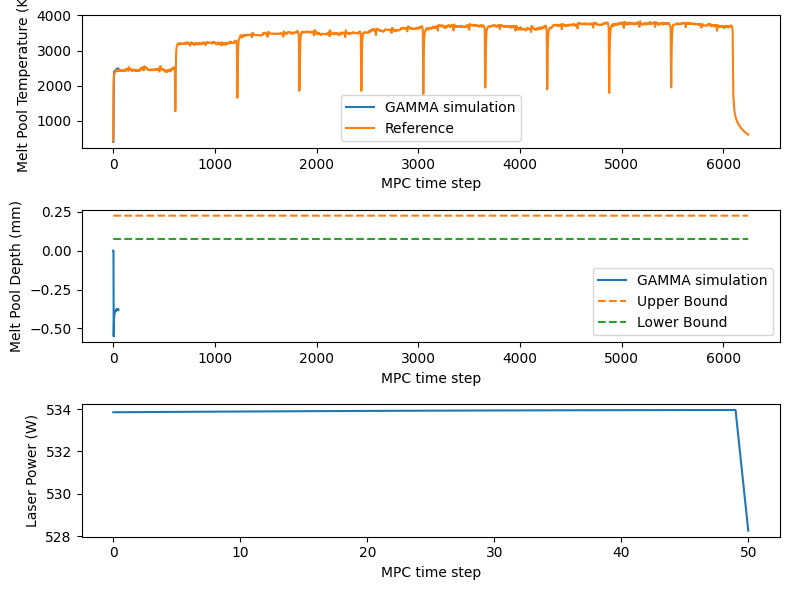

Laser 1:   8%|▊         | 500/6195 [00:56<10:51,  8.74it/s]

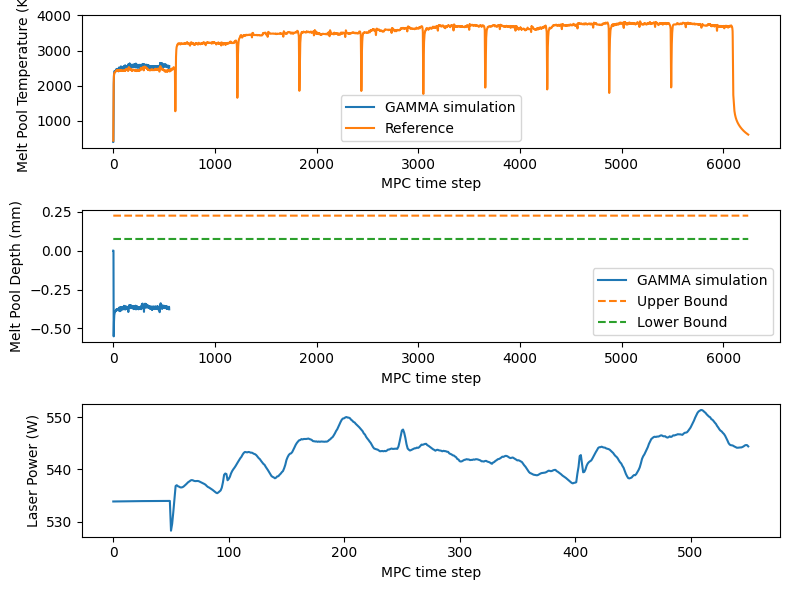

Laser 1:  16%|█▌        | 1000/6195 [01:56<10:21,  8.36it/s]

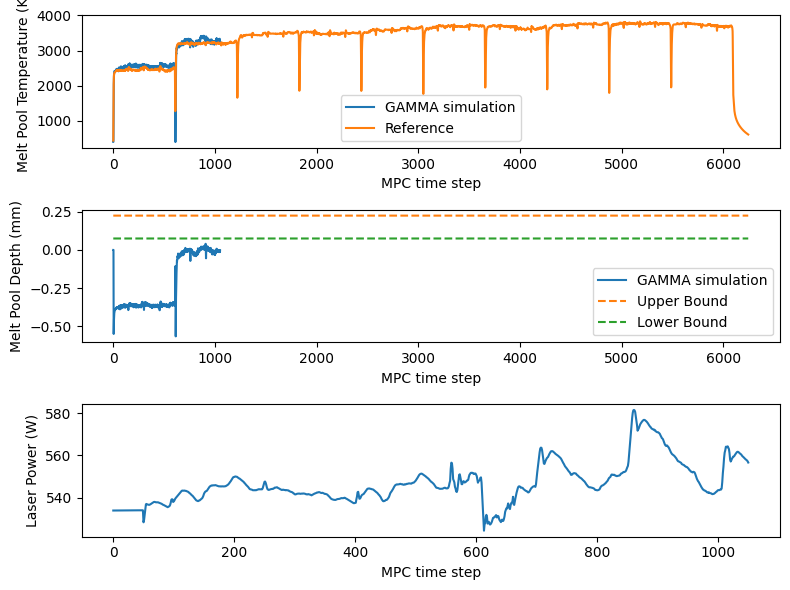

Laser 1:  24%|██▍       | 1500/6195 [02:57<09:41,  8.08it/s]

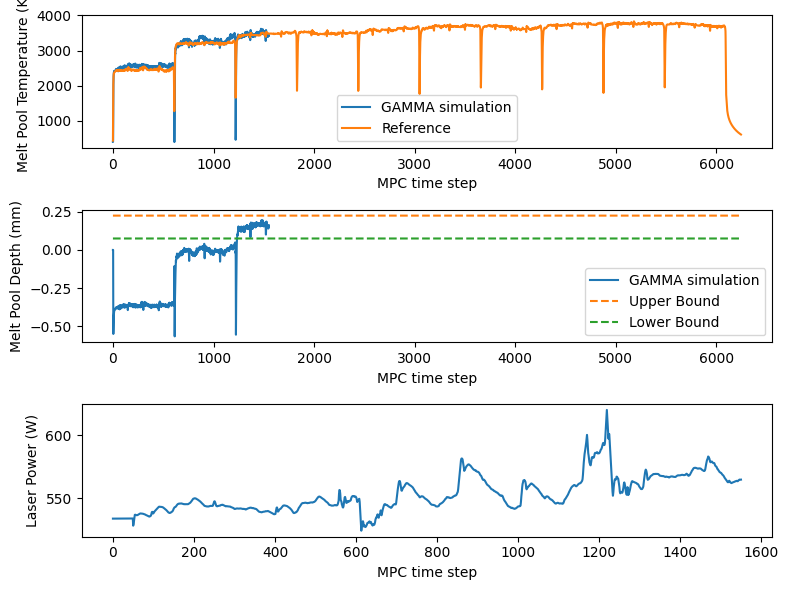

Laser 1:  32%|███▏      | 2000/6195 [04:00<08:56,  7.82it/s]

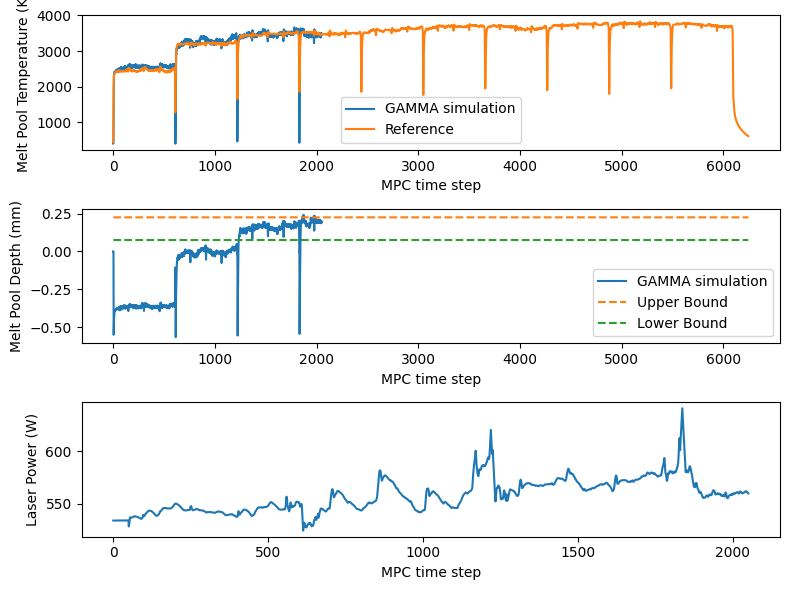

Laser 1:  40%|████      | 2500/6195 [05:05<08:08,  7.56it/s]

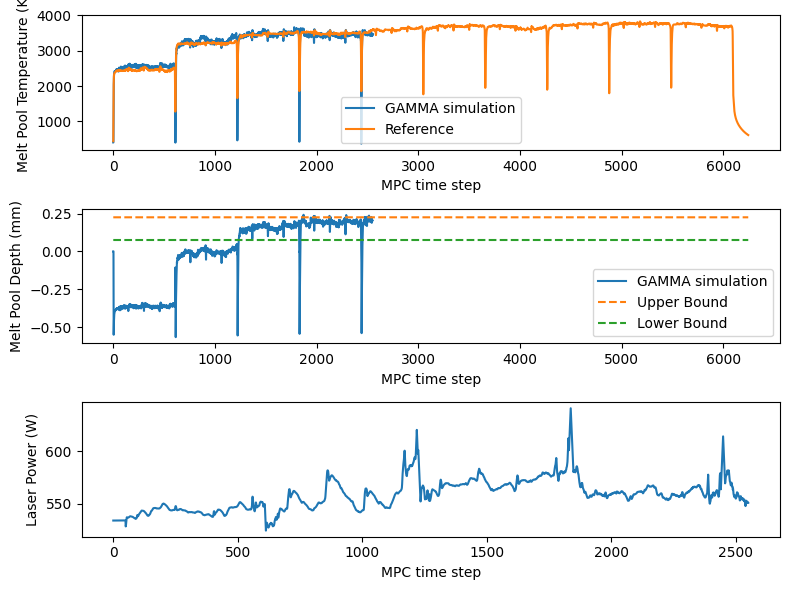

Laser 1:  48%|████▊     | 3000/6195 [06:12<06:27,  8.24it/s]

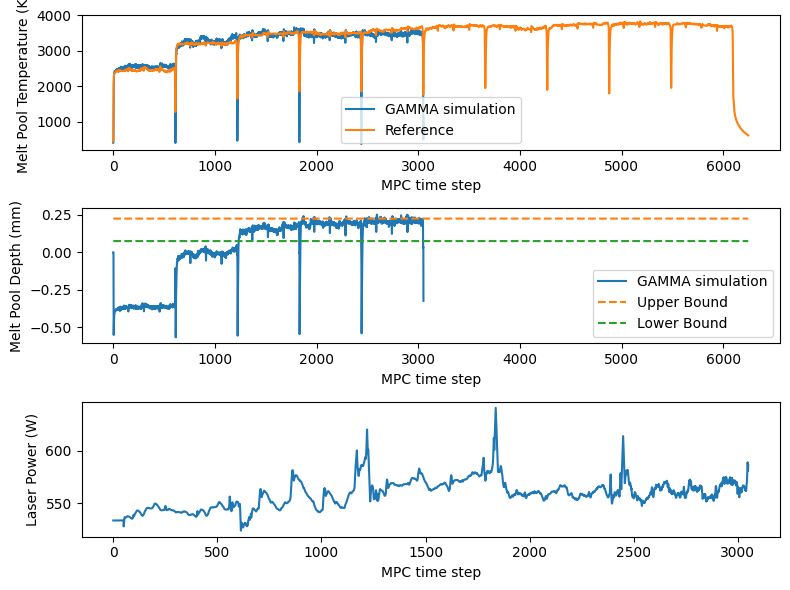

Laser 1:  56%|█████▋    | 3500/6195 [07:19<06:04,  7.40it/s]

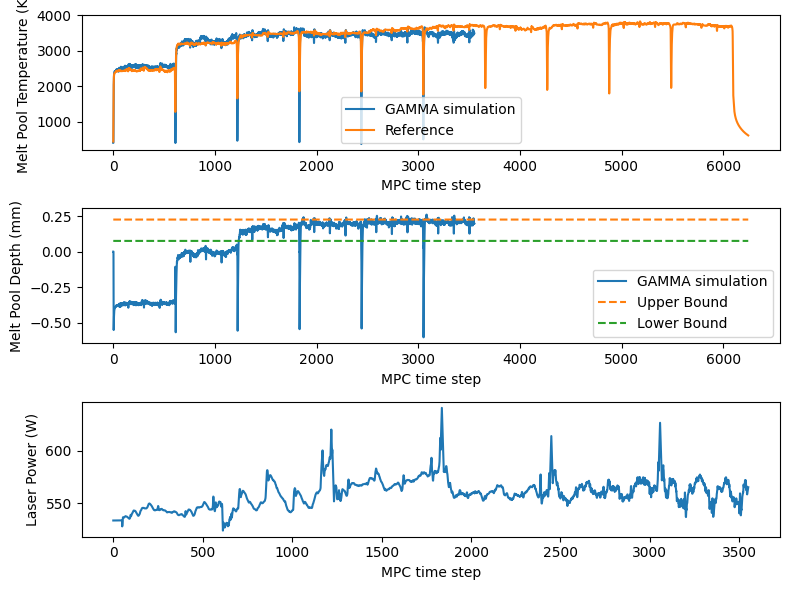

Laser 1:  65%|██████▍   | 4000/6195 [08:28<05:01,  7.29it/s]

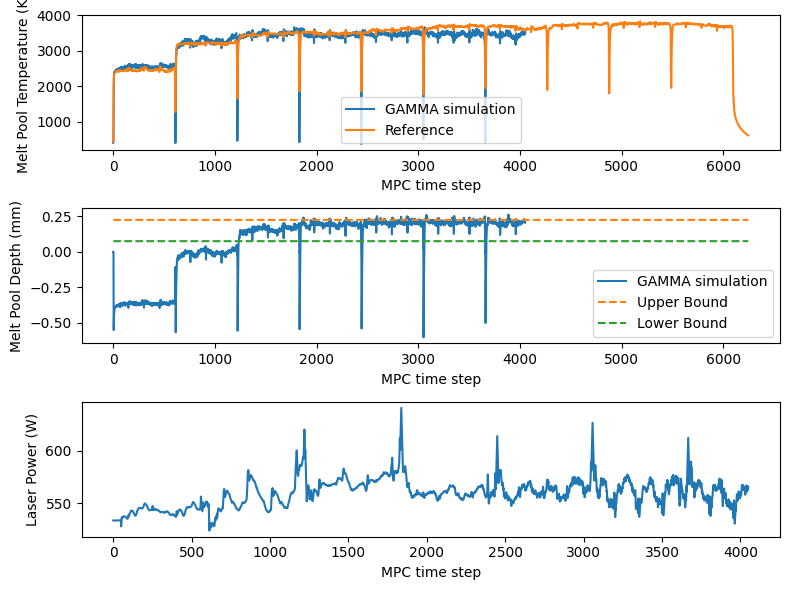

Laser 1:  73%|███████▎  | 4500/6195 [09:37<03:59,  7.09it/s]

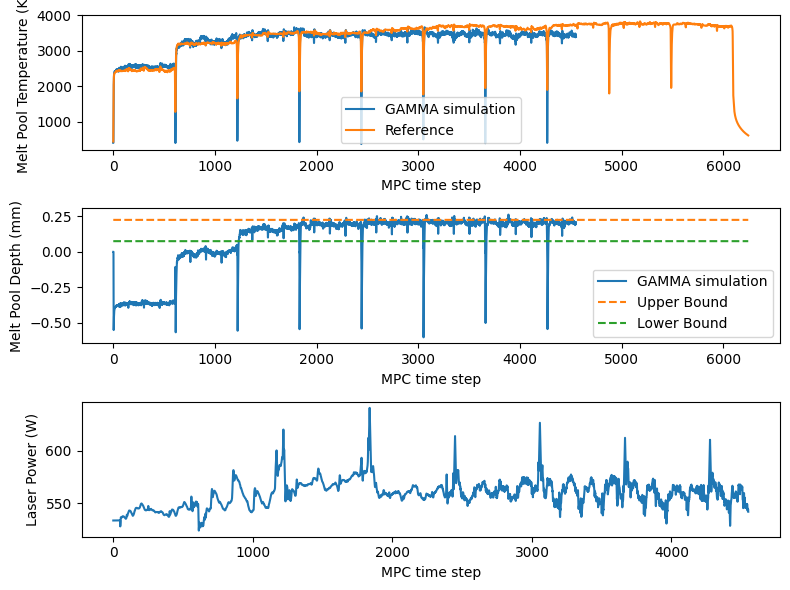

Laser 1:  81%|████████  | 5000/6195 [10:48<02:50,  7.02it/s]

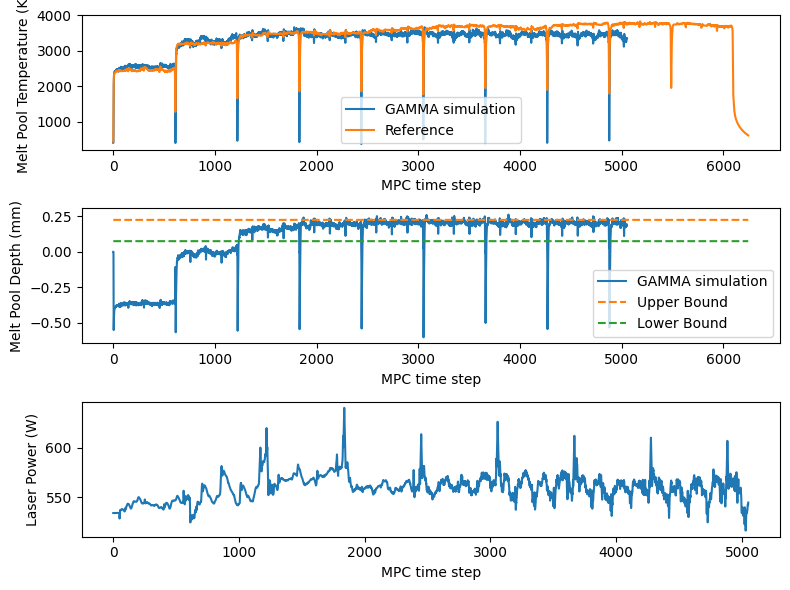

Laser 1:  89%|████████▉ | 5500/6195 [11:59<01:39,  6.97it/s]

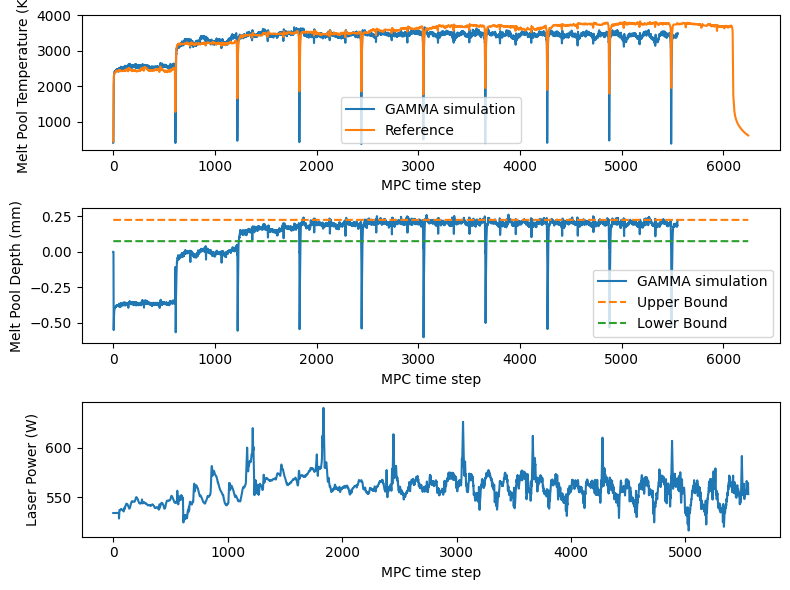

Laser 1:  97%|█████████▋| 6000/6195 [13:12<00:28,  6.87it/s]

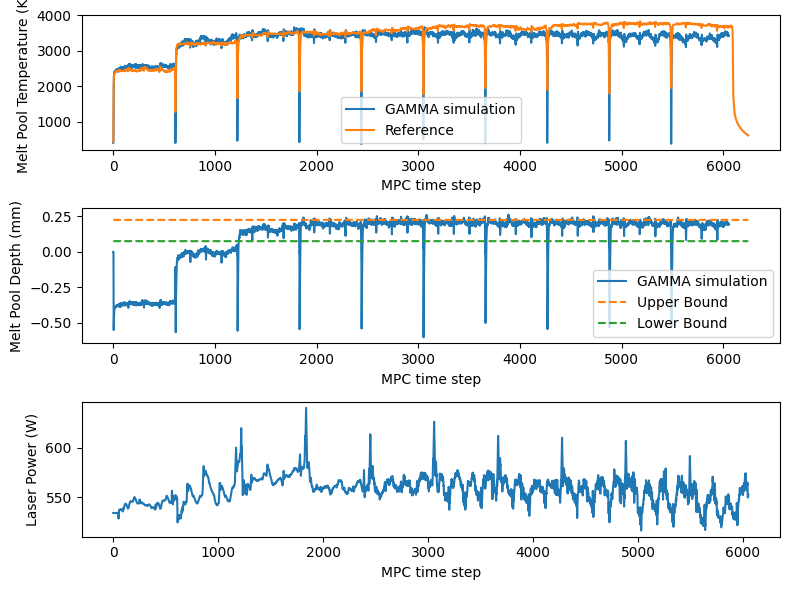

Laser 1: 100%|██████████| 6195/6195 [13:38<00:00,  7.56it/s]


Saved plot to /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/time/addnoise/policy_roll_epoch0299.pth_clamped(1)/final_plot_laser_1.png
              Time
count  6195.000000
mean      0.000571
std       0.000161
min       0.000490
25%       0.000533
50%       0.000543
75%       0.000559
max       0.003700
✅ Completed and saved for laser_power_number 1


In [17]:


# ── Constants ─────────────────────────────────────
INPUT_DATA_DIR = "data"
SIM_DIR_NAME = "single_track_square"
BASE_LASER_FILE_DIR = "laser_power_profiles/csv"
CLOUD_TARGET_BASE_PATH = "result"
solidus_temp = 1600
window = 50
sim_interval = 5
init_runs = 50
P = 50

model_path = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/policy_roll_epoch0299.pth"

# ── Load model ─────────────────────────────────────
ckpt = torch.load(model_path, map_location=device)
model = PolicyNN(
    past_input_dim=6,
    future_input_dim=6,
    output_dim=1,
    p=P,
    window=window,
    hidden_dim=1024,
    n_layers=3,
    dropout_p=0.0
).to(device)

state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)

#ckpt = torch.load(model_path)
#model.load_state_dict(ckpt["model_state_dict"])


model.eval()

# ── Output directory ───────────────────────────────
save_dir = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/time/addnoise/policy_roll_epoch0299.pth_clamped(1)"
os.makedirs(save_dir, exist_ok=True)

# ── Loop over laser_power_number 2 to 30 ───────────
for laser_num in range(1,2):
    try:
        # Step 1: Load input CSV
        csv_path = f"/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/split_by_laser_power_number/laser_power_number_{laser_num}.csv"
        df = pd.read_csv(csv_path)

        # Step 2: Instantiate GAMMA class
        GAMMA_class = GAMMA_obj(INPUT_DATA_DIR, SIM_DIR_NAME, BASE_LASER_FILE_DIR,
                                CLOUD_TARGET_BASE_PATH, solidus_temp, window,
                                init_runs, sim_interval, laser_power_number=laser_num)

        # Step 3: Run initial steps
        init_avg = GAMMA_class.run_initial_steps()
        init_avg = torch.tensor(init_avg, dtype=torch.float32).to(device)[:, -window:]

        # Step 4: Prepare inputs
        loc_Z = df["Z"].to_numpy().reshape(-1, 1)
        dist_X = df["Dist_to_nearest_X"].to_numpy().reshape(-1, 1)
        dist_Y = df["Dist_to_nearest_Y"].to_numpy().reshape(-1, 1)
        fix_covariates = torch.tensor(np.concatenate((loc_Z, dist_X, dist_Y), axis=1), dtype=torch.float32).to(device)

        laser_power_ref = torch.tensor(df["Laser_power"].to_numpy().reshape(-1, 1), dtype=torch.float32).to(device)
        laser_power_past = laser_power_ref[:window]

        mp_temp_raw = df["melt_pool_temperature"].to_numpy()
        mp_temp = copy.deepcopy(mp_temp_raw)
        mp_temp[1:-2] = moving_average_1d(mp_temp_raw, 4)
        mp_temp_ref = torch.tensor(mp_temp, dtype=torch.float32).to(device)

        # ---- depth는 있으면 만들고, 없으면 스킵 ----
        if "melt_pool_depth" in df.columns:
            mp_depth_raw = df["melt_pool_depth"].to_numpy()
            mp_depth = copy.deepcopy(mp_depth_raw)
            mp_depth[1:-2] = moving_average_1d(mp_depth_raw, 4)
            mp_depth_ref = torch.tensor(mp_depth, dtype=torch.float32).to(device)
        else:
            mp_depth_ref = None
            print(f"[WARN] laser {laser_num}: 'melt_pool_depth' column not found -> skip depth.")


        # Step 5: Initialize GAMMA_class variables
        GAMMA_class.ref = mp_temp_ref.clone().to(device)
        GAMMA_class.fix_cov_all = fix_covariates.clone().to(device)
        GAMMA_class.x_past = init_avg.clone().to(device)
        GAMMA_class.u_past = laser_power_past.clone().to(device)
        GAMMA_class.x_past_save = GAMMA_class.x_past.T.clone().to(device)
        GAMMA_class.u_past_save = GAMMA_class.u_past.clone().to(device)
        GAMMA_class.MPC_counter = window
        GAMMA_class.x_hat_current = GAMMA_class.x_past[:, -1].to(device)
        GAMMA_class.x_sys_current = GAMMA_class.x_past[:, -1].reshape(2, 1).to(device)
        GAMMA_class.save_time = []

        # 측정 노이즈용 RNG (laser별 seed 분리 → 재현 가능)
        GAMMA_class.meas_rng = np.random.default_rng(NOISE_SEED_BASE + laser_num)
        # (선택) ground truth 저장 버퍼 — x_past_save와 동일하게 시작
        GAMMA_class.x_true_save = GAMMA_class.x_past_save.clone()

        print(f"[DEBUG] laser {laser_num} save types:")
        print("  x_past_save:", type(GAMMA_class.x_past_save))
        print("  u_past_save:", type(GAMMA_class.u_past_save))
        print("  ref:", type(GAMMA_class.ref))


        # Step 6: Run simulation loop
        N_step = len(mp_temp_ref) - P
        for i in tqdm(range(N_step - P), desc=f"Laser {laser_num}"):
            run_one_step_policy(GAMMA_class, model, P=P, window=window)
            if i % 500 == 0:
                plot_fig(GAMMA_class, N_step)   # ✅ 중간 출력(화면) 그대로

        # ✅ 최종 플롯만 save_dir에 저장
        final_plot_path = os.path.join(save_dir, f"final_plot_laser_{laser_num}.png")
        plot_fig(GAMMA_class, N_step, save_path=final_plot_path)

        # Step 7: Save outputs
        x_save = GAMMA_class.x_past_save.detach().cpu().numpy()
        u_save = GAMMA_class.u_past_save.detach().cpu().numpy()
        ref_save = GAMMA_class.ref.detach().cpu().numpy()

        # ✅ 시간 저장
        df_time = pd.DataFrame({'Time': GAMMA_class.save_time})
        print(df_time.describe())  # 평균/min/max 바로 확인
        df_time.to_csv(
            os.path.join(save_dir, f"policy_time_laser_{laser_num}.csv"), index=False)

        pd.DataFrame(x_save).to_csv(
            os.path.join(save_dir, f"x_outputs_laser_{laser_num}.csv"), index=False)
        pd.DataFrame(u_save).to_csv(
            os.path.join(save_dir, f"u_outputs_laser_{laser_num}.csv"), index=False)
        pd.DataFrame(ref_save).to_csv(
            os.path.join(save_dir, f"ref_laser_{laser_num}.csv"), index=False)
        # (선택) ground truth 저장
        if hasattr(GAMMA_class, "x_true_save"):
            xtrue_save = GAMMA_class.x_true_save.detach().cpu().numpy()
            pd.DataFrame(xtrue_save).to_csv(
                os.path.join(save_dir, f"x_true_outputs_laser_{laser_num}.csv"), index=False)


        print(f"✅ Completed and saved for laser_power_number {laser_num}")

    except Exception as e:
        print(f"❌ Error in laser_power_number {laser_num}: {e}")
